In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process.kernels import (
    WhiteKernel, ConstantKernel, RBF, RationalQuadratic, ExpSineSquared, DotProduct
)
from auto_kernel_ensemble import KernelAutoregressiveModel
from data_loader import DataLoader
from walk_forward import WalkForwardValidator
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from metrics import ForecastingMetrics

In [47]:
# read in the data for the below ticker
portfolio_assets = [
        'ACM',
        'OSK',
        'PATH',
        'RGLD',
        'AAAU',
        'CIBR',
        'IBIT',
        'ITA',
        'SGDM',
        'USO',
        'USXF',
        'XHE'
    ]
# load the data
assets = {}
for ticker in portfolio_assets:
    try:
        df_asset = pd.read_parquet(f'data/{ticker}.parquet')
        if df_asset.shape[0] < 3500:
            print(f'Skipping {ticker} as it has less than 3500 rows')
            continue
        else:
            assets[ticker] = df_asset
    except Exception as e:
        print(f'Error reading {ticker}: {e}')

Skipping PATH as it has less than 3500 rows
Skipping AAAU as it has less than 3500 rows
Skipping CIBR as it has less than 3500 rows
Skipping IBIT as it has less than 3500 rows
Skipping SGDM as it has less than 3500 rows
Skipping USXF as it has less than 3500 rows


In [48]:
# get general stats
for ticker in assets.keys():
    print(f'Ticker: {ticker}')
    print(assets[ticker].describe())

Ticker: ACM
         Adj Close        Close         High          Low         Open  \
count  4675.000000  4675.000000  4675.000000  4675.000000  4675.000000   
mean     43.697667    44.908257    45.452712    44.339641    44.897001   
std      26.671313    26.808504    27.041514    26.591937    26.819384   
min      14.383489    14.910000    15.030000    14.430000    14.590000   
25%      26.914778    27.900000    28.255000    27.460000    27.860001   
50%      31.265520    32.410000    32.790001    32.009998    32.410000   
75%      59.781677    61.970001    62.810001    61.310001    62.080000   
max     134.350006   134.350006   135.520004   132.919998   134.240005   

             Volume  
count  4.675000e+03  
mean   9.975093e+05  
std    7.607348e+05  
min    1.364000e+05  
25%    5.907000e+05  
50%    8.125000e+05  
75%    1.155100e+06  
max    2.000790e+07  
Ticker: OSK
          Adj Close         Close          High           Low          Open  \
count  10124.000000  10124.00000

In [49]:
assets_train = {}
assets_test = {}
assets_validation = {}
assets_analysis = {}
for ticker in assets.keys():
    # split the dat into train and test sets
    split_record = -2500 # int(len(df_asset)*0.8)
    df_asset_train = assets[ticker].iloc[:split_record]
    df_asset_test = assets[ticker].iloc[split_record:]

    # split the training into analysis and validation sets
    split_record2 = int(len(df_asset_train)*0.8)
    df_asset_train_analysis = df_asset_train.iloc[:split_record2]
    df_asset_train_validation = df_asset_train.iloc[split_record2:]
    assets_analysis[ticker] = df_asset_train_analysis
    assets_validation[ticker] = df_asset_train_validation
    assets_train[ticker] = df_asset_train
    assets_test[ticker] = df_asset_test
    print (
        f'Ticker: {ticker}\n'
        f'Train set size: {len(df_asset_train)}\n'
        f'Test set size: {len(df_asset_test)}\n'
        f'Train set analysis size: {len(df_asset_train_analysis)}\n'
        f'Train set validation size: {len(df_asset_train_validation)}'
        f'\n'
    )

Ticker: ACM
Train set size: 2175
Test set size: 2500
Train set analysis size: 1740
Train set validation size: 435

Ticker: OSK
Train set size: 7624
Test set size: 2500
Train set analysis size: 6099
Train set validation size: 1525

Ticker: RGLD
Train set size: 8716
Test set size: 2500
Train set analysis size: 6972
Train set validation size: 1744

Ticker: ITA
Train set size: 2429
Test set size: 2500
Train set analysis size: 1943
Train set validation size: 486

Ticker: USO
Train set size: 2447
Test set size: 2500
Train set analysis size: 1957
Train set validation size: 490

Ticker: XHE
Train set size: 1238
Test set size: 2500
Train set analysis size: 990
Train set validation size: 248



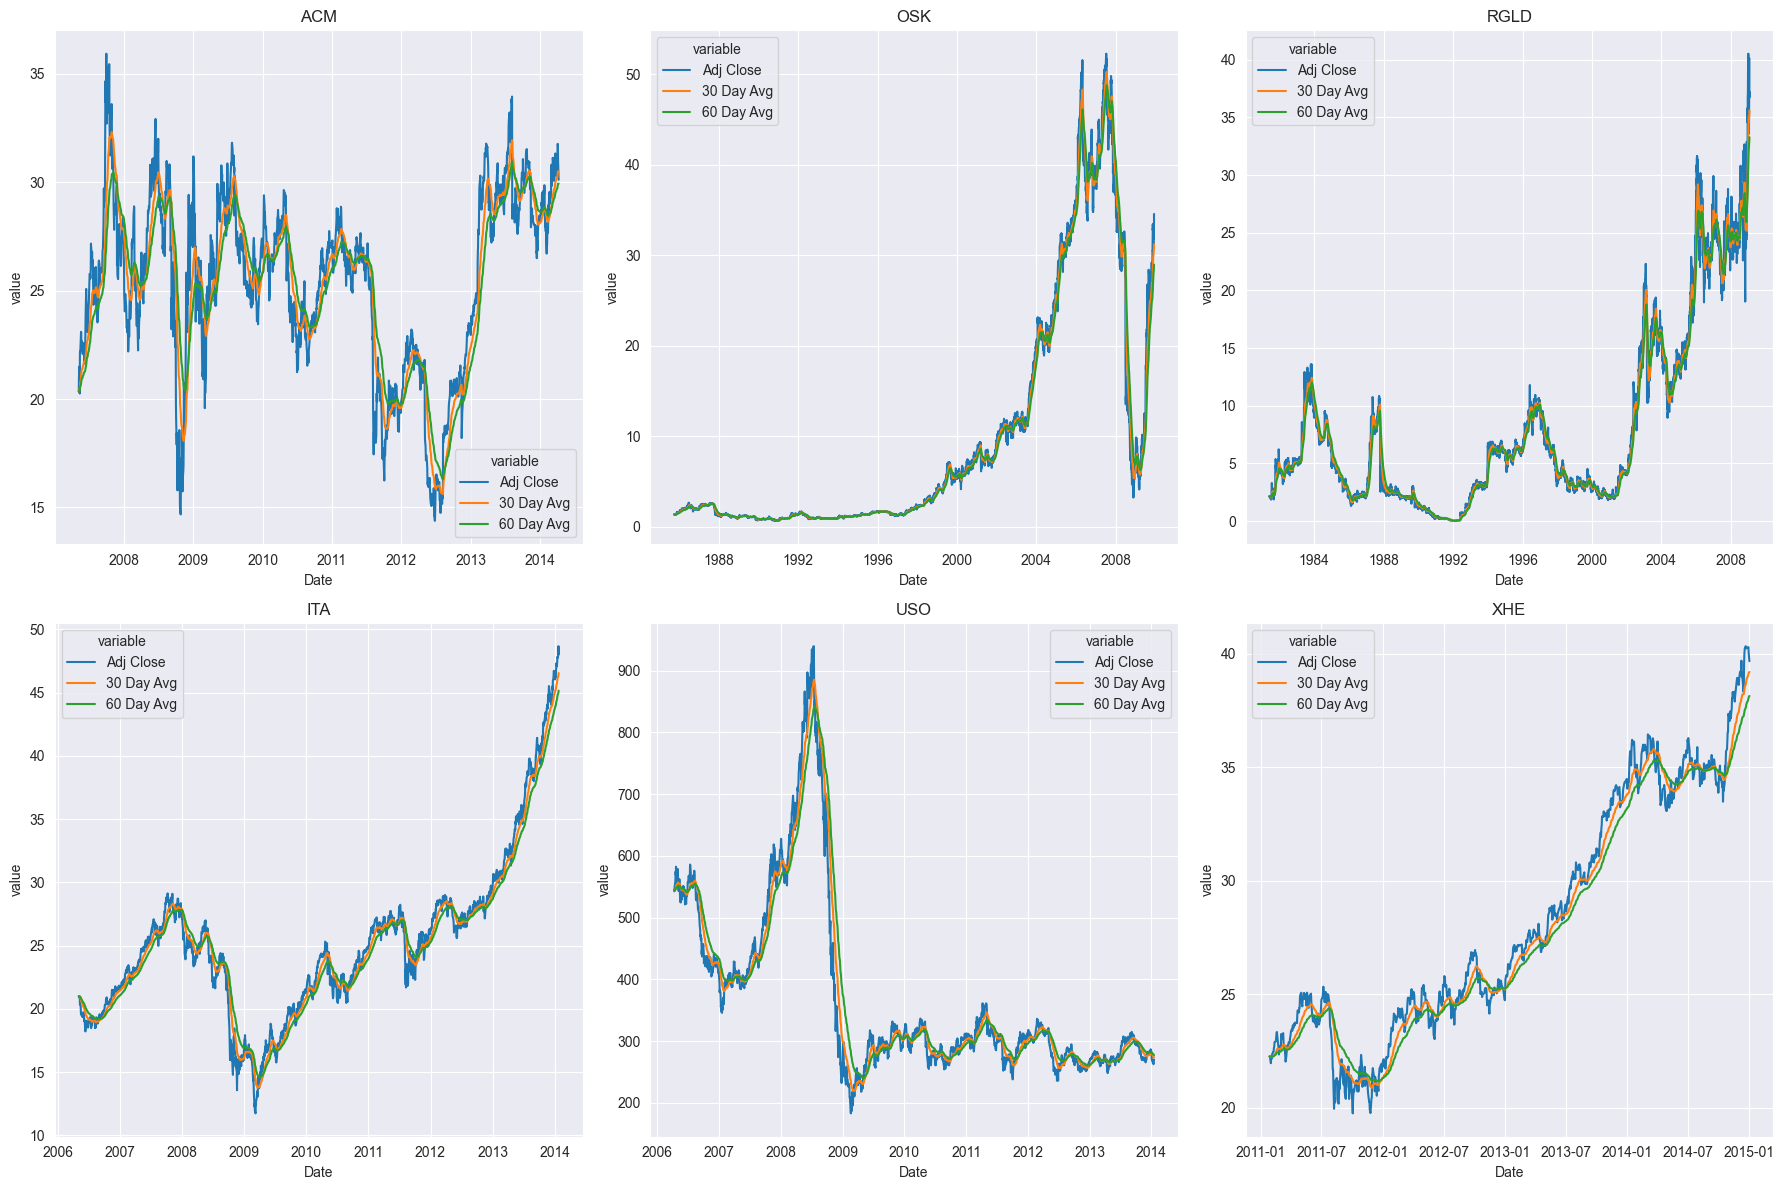

In [50]:
# plot the asset price. There should be the actual, the 30 day moving average, and the 60 day moving avg
# df_asset_train_analysis['30 Day Avg'] = df_asset_train_analysis['Adj Close'].rolling(window=30).mean()
# df_asset_train_analysis['60 Day Avg'] = df_asset_train_analysis['Adj Close'].rolling(window=60).mean()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
for counter, ticker in enumerate(assets_analysis.keys()):
    df_tmp = assets_analysis[ticker].reset_index()
    df_tmp['30 Day Avg'] = df_tmp['Adj Close'].ewm(span=30, adjust=False).mean()
    df_tmp['60 Day Avg'] = df_tmp['Adj Close'].ewm(span=60, adjust=False).mean()

    # df_tmp['30 Day Avg'] = df_tmp['Adj Close'].rolling(window=30).mean()
    # df_tmp['60 Day Avg'] = df_tmp['Adj Close'].rolling(window=60).mean()
    assets_analysis[ticker] = df_tmp
    # melt the data
    # df_tmp = assets_analysis[ticker].reset_index()
    df_melted = pd.melt(df_tmp, id_vars=['Date'], value_vars=['Adj Close', '30 Day Avg', '60 Day Avg'])
    sns.lineplot(data=df_melted, x='Date', y='value', hue='variable', ax=axes[counter]).set_title(ticker)

plt.tight_layout()
plt.savefig(f"plots/training_data_rgld.png")
plt.show()

ACM Residuals:
30 Day Residuals: count    1740.000000
mean       -0.084405
std         1.631020
min        -7.364812
25%        -1.034507
50%        -0.209509
75%         0.868515
max         6.814045
Name: 30 Day Residuals, dtype: float64
60 Day Residuals: count    1740.000000
mean       -0.162544
std         2.197422
min        -8.730142
25%        -1.497043
50%        -0.330936
75%         1.143703
max         9.146948
Name: 60 Day Residuals, dtype: float64
OSK Residuals:
30 Day Residuals: count    6099.000000
mean       -0.071024
std         1.093219
min        -7.372695
25%        -0.196305
50%        -0.018723
75%         0.052888
max        12.299195
Name: 30 Day Residuals, dtype: float64
60 Day Residuals: count    6099.000000
mean       -0.133596
std         1.673612
min       -10.728227
25%        -0.316545
50%        -0.032752
75%         0.070033
max        14.789546
Name: 60 Day Residuals, dtype: float64
RGLD Residuals:
30 Day Residuals: count    6972.000000
mean       -0.0

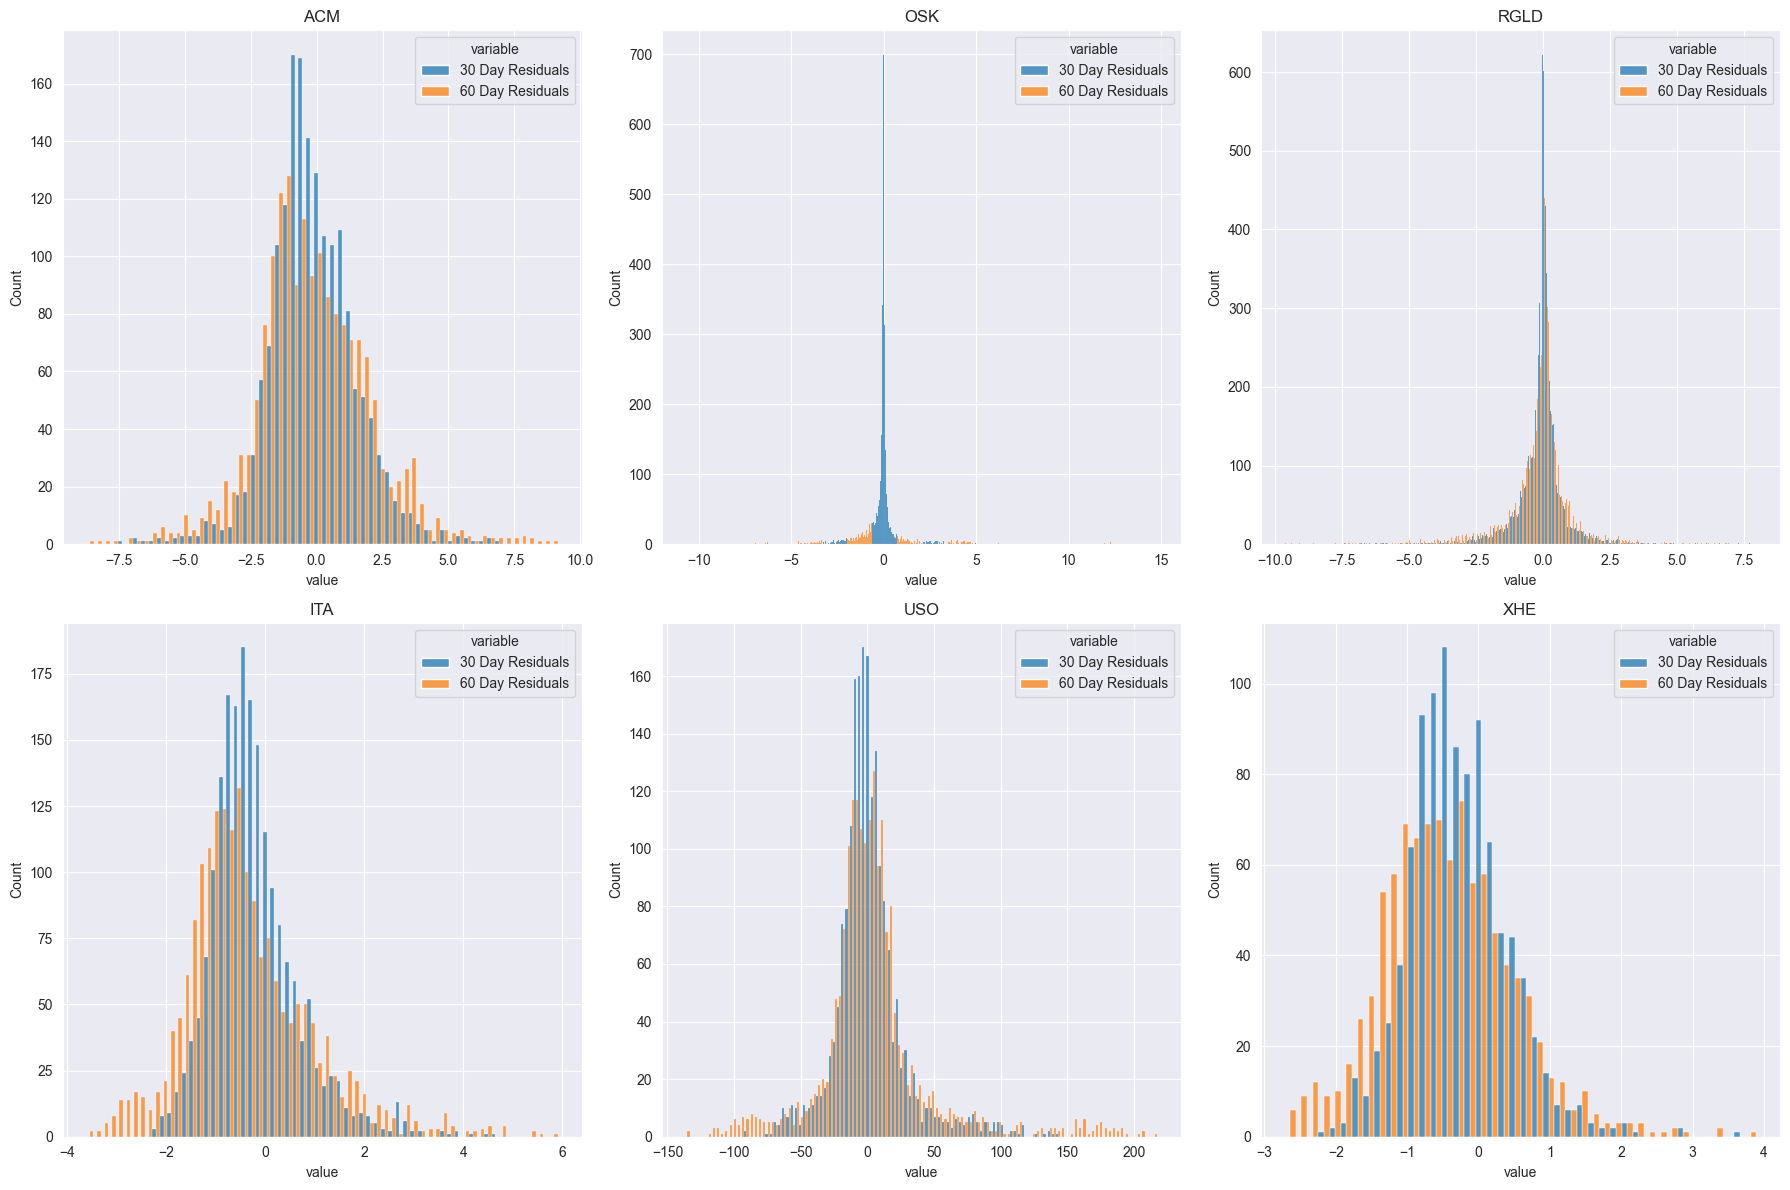

In [51]:
# plot the residuals between the avgs and the actual variable
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
for counter, ticker in enumerate(assets_analysis.keys()):
    df_tmp = assets_analysis[ticker]
    df_tmp['30 Day Residuals'] = df_tmp['30 Day Avg'] - df_tmp['Adj Close']
    df_tmp['60 Day Residuals'] = df_tmp['60 Day Avg'] - df_tmp['Adj Close']
    print(f"{ticker} Residuals:\n30 Day Residuals: {df_tmp['30 Day Residuals'].describe()}\n60 Day Residuals: {df_tmp['60 Day Residuals'].describe()}")
    df_melted = pd.melt(df_tmp, id_vars=['Date'], value_vars=['30 Day Residuals', '60 Day Residuals'])
    sns.histplot(data=df_melted, x='value', hue='variable', multiple='dodge', ax=axes[counter]).set_title(ticker)
plt.tight_layout()
plt.savefig(f"plots/training_data_residuals_rgld.png")
plt.show()


/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_81904/3662363008.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_train_analysis['Running Mean'] = mean_vals
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_81904/3662363008.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_train_analysis['Running Median'] = meadian_vals


<Axes: xlabel='Date'>

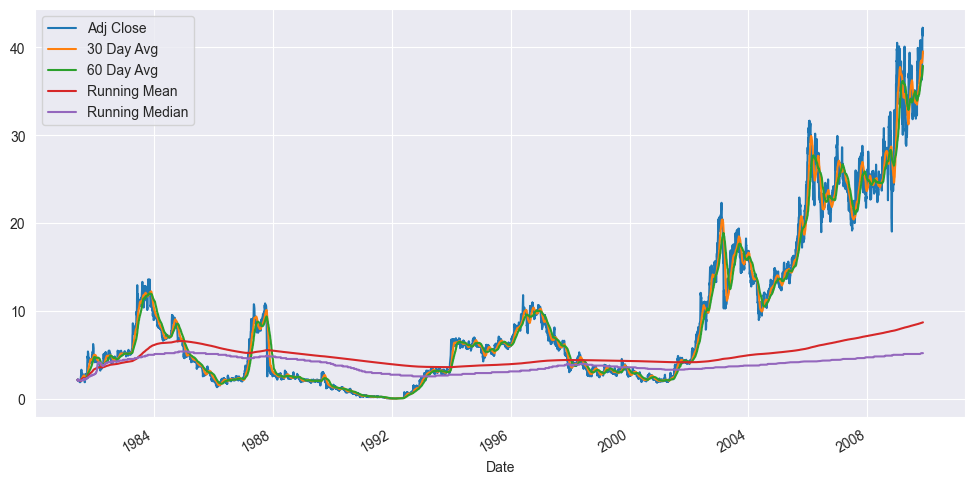

In [7]:
# calculate the running mean and median of the adj close price using a growing window
ending_index = 0
growing_window = [(0, x) for x in range(df_asset_train_analysis.shape[0]) if x >= ending_index]
meadian_vals = []
mean_vals = []
for window in growing_window:
    mean_vals.append(df_asset_train_analysis['Adj Close'][window[0]:window[1]].mean())
    meadian_vals.append(df_asset_train_analysis['Adj Close'][window[0]:window[1]].median())

# add a a column
df_asset_train_analysis['Running Mean'] = mean_vals
df_asset_train_analysis['Running Median'] = meadian_vals
df_asset_train_analysis[['Adj Close', '30 Day Avg', '60 Day Avg', 'Running Mean', 'Running Median']].plot(figsize=(12, 6))

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_81904/3225785681.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_train_analysis['Adj Close Normalized'] = scaler.fit_transform(df_asset_train_analysis[['Adj Close']])


<Axes: xlabel='Date'>

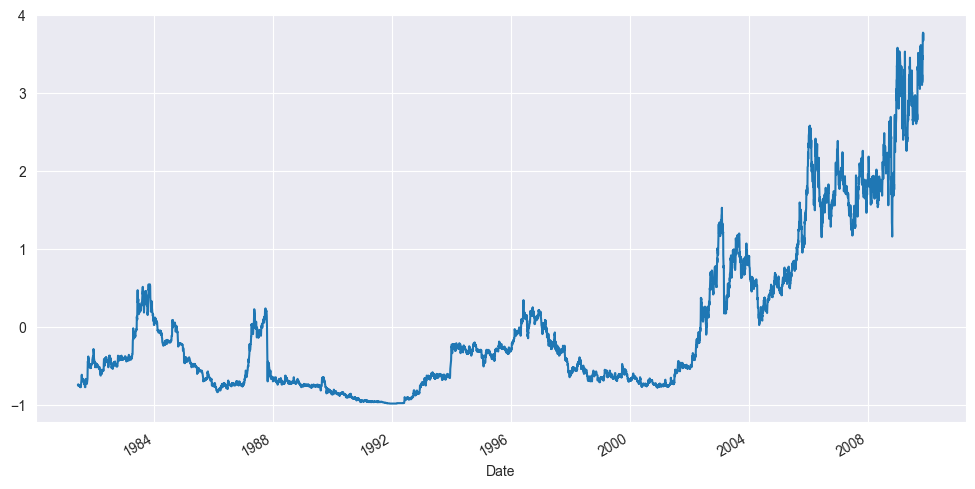

In [9]:
# standardarize the Adj close price then plot the running mean  of the normalized values
scaler = StandardScaler()
df_asset_train_analysis['Adj Close Normalized'] = scaler.fit_transform(df_asset_train_analysis[['Adj Close']])
df_asset_train_analysis['Adj Close Normalized'].plot(figsize=(12, 6))

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_81904/126024567.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_train_analysis['30 Day Avg'] = df_asset_train_analysis['Adj Close Normalized'].rolling(window=30).mean()
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_81904/126024567.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_train_analysis['60 Day Avg'] = df_asset_train_analysis['Adj Close Normalized'].rolling(window=60).mean()
/var/folders/h3/n4kr77l914l79r

<Axes: xlabel='Date'>

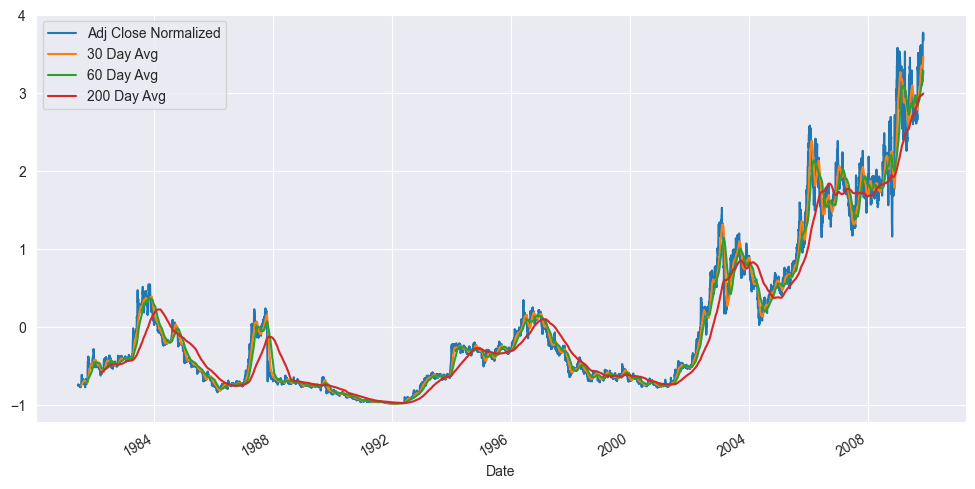

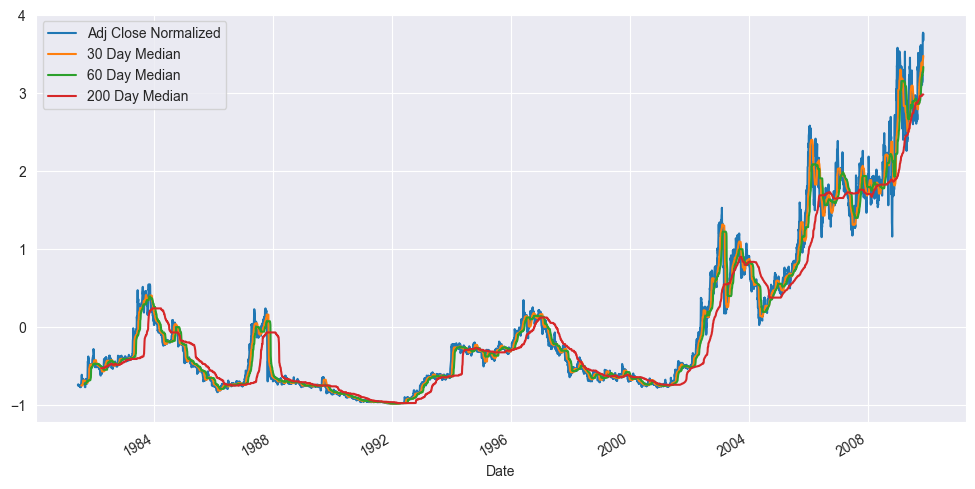

In [10]:
# smooth the values
df_asset_train_analysis['30 Day Avg'] = df_asset_train_analysis['Adj Close Normalized'].rolling(window=30).mean()
df_asset_train_analysis['60 Day Avg'] = df_asset_train_analysis['Adj Close Normalized'].rolling(window=60).mean()
df_asset_train_analysis['200 Day Avg'] = df_asset_train_analysis['Adj Close Normalized'].rolling(window=200).mean()

df_asset_train_analysis['30 Day Median'] = df_asset_train_analysis['Adj Close Normalized'].rolling(window=30).median()
df_asset_train_analysis['60 Day Median'] = df_asset_train_analysis['Adj Close Normalized'].rolling(window=60).median()
df_asset_train_analysis['200 Day Median'] = df_asset_train_analysis['Adj Close Normalized'].rolling(window=200).median()

mean_columns = ['Adj Close Normalized', '30 Day Avg', '60 Day Avg', '200 Day Avg']
median_columns = ['Adj Close Normalized', '30 Day Median', '60 Day Median', '200 Day Median']
df_asset_train_analysis[mean_columns].plot(figsize=(12, 6))
df_asset_train_analysis[median_columns].plot(figsize=(12, 6))

## Modeling Methodology

The modeling method is from the perspective of a long-term investor who is looking to maximize his/her/their wealth over time via proper rebalancing of assets in a portfolio of etfs and stocks. The goal of this study is to outperform a bench-mark methodology of buy and hold through statistical rebalancing.
The statistical method is inspired by the well-known strategy of buying assets when they are cheap and selling them when they are expensive. The first two questions at hand, as to how to approach this problem with quantitative mesures are the following. How do you measure a good time to sell vs when to buy? The mean or median z-score of all known prices answers this. When the current price is k standard deviations away from the mean, that will trigger a buy or sell opportunity. A tuneable parameter to suit the investors' risk vs return tolerance.
To rebalance the portfolio, the mean-variance expected portfolio return will be used to find the optimal number of shares to purchase for each asset. The assets considered for optimization are those with buy and/or sell signals. For neutral unchanged assets will be held until significant price changes occur.

## Asset Performance Metrics (Continuous list):

- Keep track of the lots of shares bought for buy transactions. This metric could be used to do additional testing of FIFO and LIFO methodologies. Some shares will be bought at different prices

## Auto Regression with kernels

The main goal of the following analysis is to find the lags that are ideal for forecasting future prices of the asset.

- Produce both auto and partial autocorrelations to find the ideal number of lags for predicting future prices
- Perform the feature transformations to get the lags
- Evaluate if there are any relationships with the lags of a smoothed volume
- Evaluate the features under different kernels. Do patterns emerge?
- Apply a basic kernel regression model to the future prices in a casaul manner


In [36]:
independent_variables = [f'Lag {x}' for x in range(1, 15 + 1)]
# # Apply StandardScaler
for asset in assets_analysis.keys():
    scaler_y = StandardScaler()
    scaler_x = StandardScaler()
    df_tmp = assets_analysis[asset].dropna()
    df_tmp['30 Day Avg'] = scaler_y.fit_transform(df_tmp[['30 Day Avg']])
    df_tmp[independent_variables] = scaler_x.fit_transform(df_tmp[independent_variables])
    assets_analysis[asset] = {
        'data': df_tmp,
        'scaler_y': scaler_y,
        'scaler_x': scaler_x
    }
assets_analysis[asset]['data'].head()
# df_tmp[independent_variables]

,level_0,index,Date,Adj Close,Close,High,Low,Open,Volume,30 Day Avg,...,Lag 6,Lag 7,Lag 8,Lag 9,Lag 10,Lag 11,Lag 12,Lag 13,Lag 14,Lag 15
15,15,15,2011-02-17,23.287281,26.355000,26.360001,26.125,26.350000,6800,-1.081682,...,-1.119059,-1.122171,-1.123174,-1.124328,-1.124496,-1.123490,-1.120808,-1.118845,-1.113454,-1.111929
16,16,16,2011-02-18,23.335869,26.410000,26.514999,26.410,26.514999,2000,-1.071438,...,-1.114126,-1.117612,-1.120708,-1.121687,-1.122819,-1.122969,-1.121952,-1.119279,-1.117331,-1.111929
17,17,17,2011-02-22,22.765959,25.764999,25.959999,25.760,25.850000,4000,-1.069040,...,-1.106865,-1.112671,-1.116141,-1.119217,-1.120174,-1.121290,-1.121431,-1.120424,-1.117765,-1.115812
18,18,18,2011-02-23,22.611324,25.590000,25.590000,25.590,25.590000,400,-1.068746,...,-1.099735,-1.105397,-1.111191,-1.114643,-1.117700,-1.118640,-1.119749,-1.119902,-1.118913,-1.116247
19,19,19,2011-02-24,22.341833,25.285000,25.305000,25.150,25.250000,55000,-1.071868,...,-1.092615,-1.098255,-1.103906,-1.109685,-1.113119,-1.116162,-1.117096,-1.118217,-1.118389,-1.117396


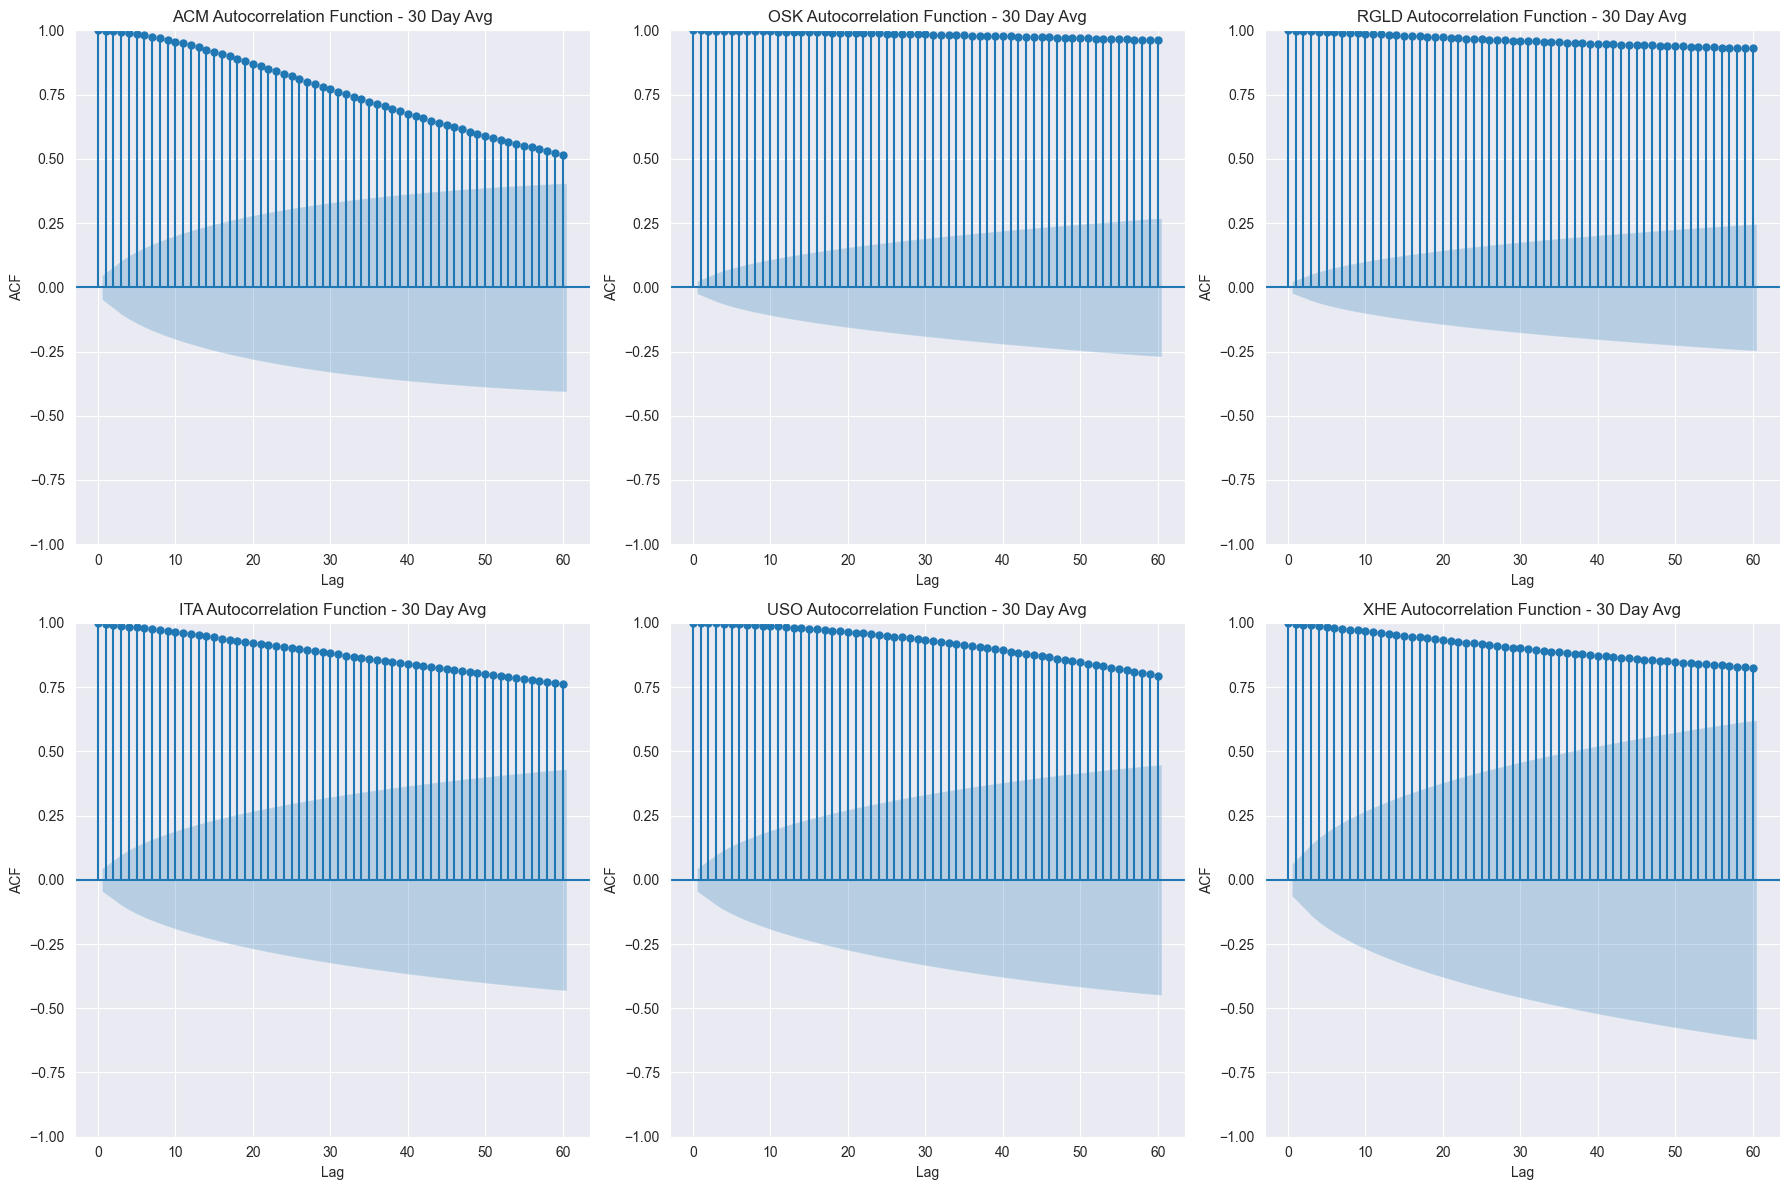

In [38]:
# data_30_day = df_asset_train_analysis['30 Day Avg'].dropna()

# Create subplots for ACF and PACF
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
for counter, ticker in enumerate(assets_analysis.keys()):
    # Plot Autocorrelation Function (ACF) with 30 lags
    plot_acf(assets_analysis[ticker]['data']['30 Day Avg'], lags=60, ax=axes[counter], title=f'{ticker} Autocorrelation Function - 30 Day Avg')
    axes[counter].set_xlabel('Lag')
    axes[counter].set_ylabel('ACF')

# # Plot Partial Autocorrelation Function (PACF) with 30 lags
# plot_pacf(data_30_day, lags=60, ax=ax2, title='Partial Autocorrelation Function - 30 Day Avg')
# ax2.set_xlabel('Lag')
# ax2.set_ylabel('PACF')

plt.tight_layout()
plt.savefig(f"plots/acf_pacf_rgld.png")
plt.show()

<Axes: xlabel='Date'>

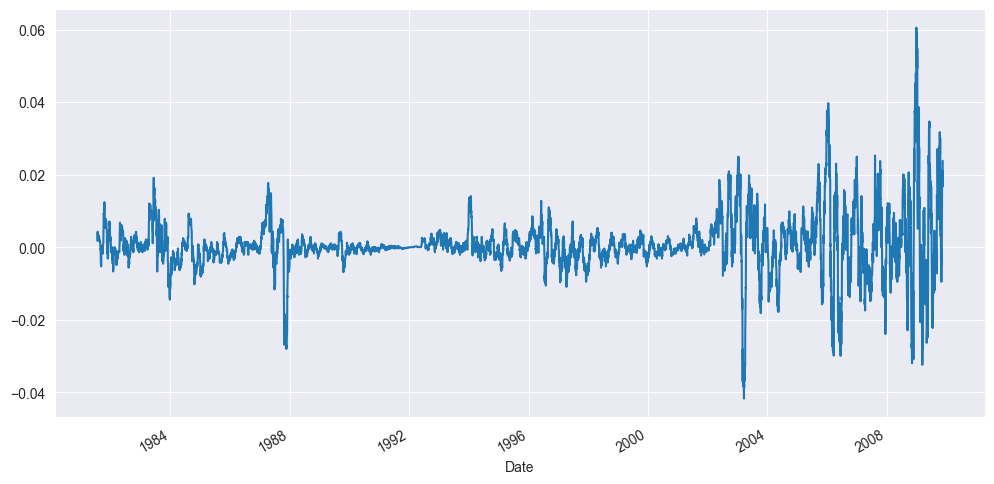

In [35]:
# plot the differencing
df_asset_train_analysis['30 Day Avg Diff'].plot(figsize=(12, 6))

In [27]:
# create the lag variables up to 15 days
lag_value = 15
for ticker in assets_analysis.keys():
    df_tmp = assets_analysis[ticker]
    for lag in range(lag_value):
        lag_val = lag + 1
        df_tmp[f'Lag {lag_val}'] = df_tmp['30 Day Avg'].shift(lag_val)
    assets_analysis[ticker] = df_tmp.dropna()

assets_analysis[ticker].head()

,level_0,index,Date,Adj Close,Close,High,Low,Open,Volume,30 Day Avg,...,Lag 6,Lag 7,Lag 8,Lag 9,Lag 10,Lag 11,Lag 12,Lag 13,Lag 14,Lag 15
15,15,15,2011-02-17,23.287281,26.355000,26.360001,26.125,26.350000,6800,22.523290,...,22.290439,22.267394,22.254948,22.241644,22.233212,22.230596,22.236331,22.238501,22.257883,22.257883
16,16,16,2011-02-18,23.335869,26.410000,26.514999,26.410,26.514999,2000,22.575715,...,22.315417,22.290439,22.267394,22.254948,22.241644,22.233212,22.230596,22.236331,22.238501,22.257883
17,17,17,2011-02-22,22.765959,25.764999,25.959999,25.760,25.850000,4000,22.587988,...,22.352180,22.315417,22.290439,22.267394,22.254948,22.241644,22.233212,22.230596,22.236331,22.238501
18,18,18,2011-02-23,22.611324,25.590000,25.590000,25.590,25.590000,400,22.589494,...,22.388281,22.352180,22.315417,22.290439,22.267394,22.254948,22.241644,22.233212,22.230596,22.236331
19,19,19,2011-02-24,22.341833,25.285000,25.305000,25.150,25.250000,55000,22.573516,...,22.424333,22.388281,22.352180,22.315417,22.290439,22.267394,22.254948,22.241644,22.233212,22.230596


## Kernels for Mean Reversion Analysis

Kernels can be used to smooth data to capture non-linear relationships as well as linear ones. They do so by capturing relationships between all the observations within a dataset. Capturing those relationships can be through a linear function or a distance measure. Below are some common and explored kernels with their definitions and descriptions:

**Constant Kernel:**

$$k(x_1, x_2) = \text{constant\_value} \quad \forall x_1, x_2$$

Combined with other kernels as a constant term.

**White Kernel:**

$$k(x_i, x_j) = \text{noise\_level} \quad \text{if } x_i == x_j \text{ else } 0$$

Combined with other kernels as white noise. Good when modeling noisy processes.

**RBF (Radial Basis Function):**

$$k(x_i, x_j) = \exp\left(-\frac{d(x_i, x_j)^2}{2l^2}\right)$$

The radial basis function, also known as the squared exponential kernel. It is one of the more popular kernels to use given its ability to capture dynamic and non-linear relationships. The kernel is capable of doing so by leveraging the euclidean distance between points. One of the main parameters to this kernel is its length parameter $l$. This parameter handles the magnitude in the changes in the relationships between points.

**Rational Quadratic:**

$$k(x_i, x_j) = \left(1 + \frac{d(x_i, x_j)^2}{2\alpha l^2}\right)^{-\alpha}$$

An even more flexible kernel in capturing relationships, given it is an infinite sum of radial basis functions. Because it is an infinite sum, it can capture many time lengths.

**Dot Product:**

$$k(x_i, x_j) = \sigma_0^2 + x_i \cdot x_j$$

Captures linear relationships via ordinary least squares.

**Exp-Sine-Squared kernel:**

$$k(x_i, x_j) = \exp\left(-\frac{2\sin^2(\pi d(x_i, x_j)/p)}{l^2}\right)$$

A kernel that is good at finding repetitive patterns within data. Like RBF and Rational quadratic, this kernel uses a length parameter $l$ in the same manner. It is also followed up with periodicity $p$, which is the length in time between repeats.

Kernels are both multiplicative and additive. When you add two kernels together, you can find a combination of relationships. Adding finds relationships using an OR statement and multiplication is with an AND condition.

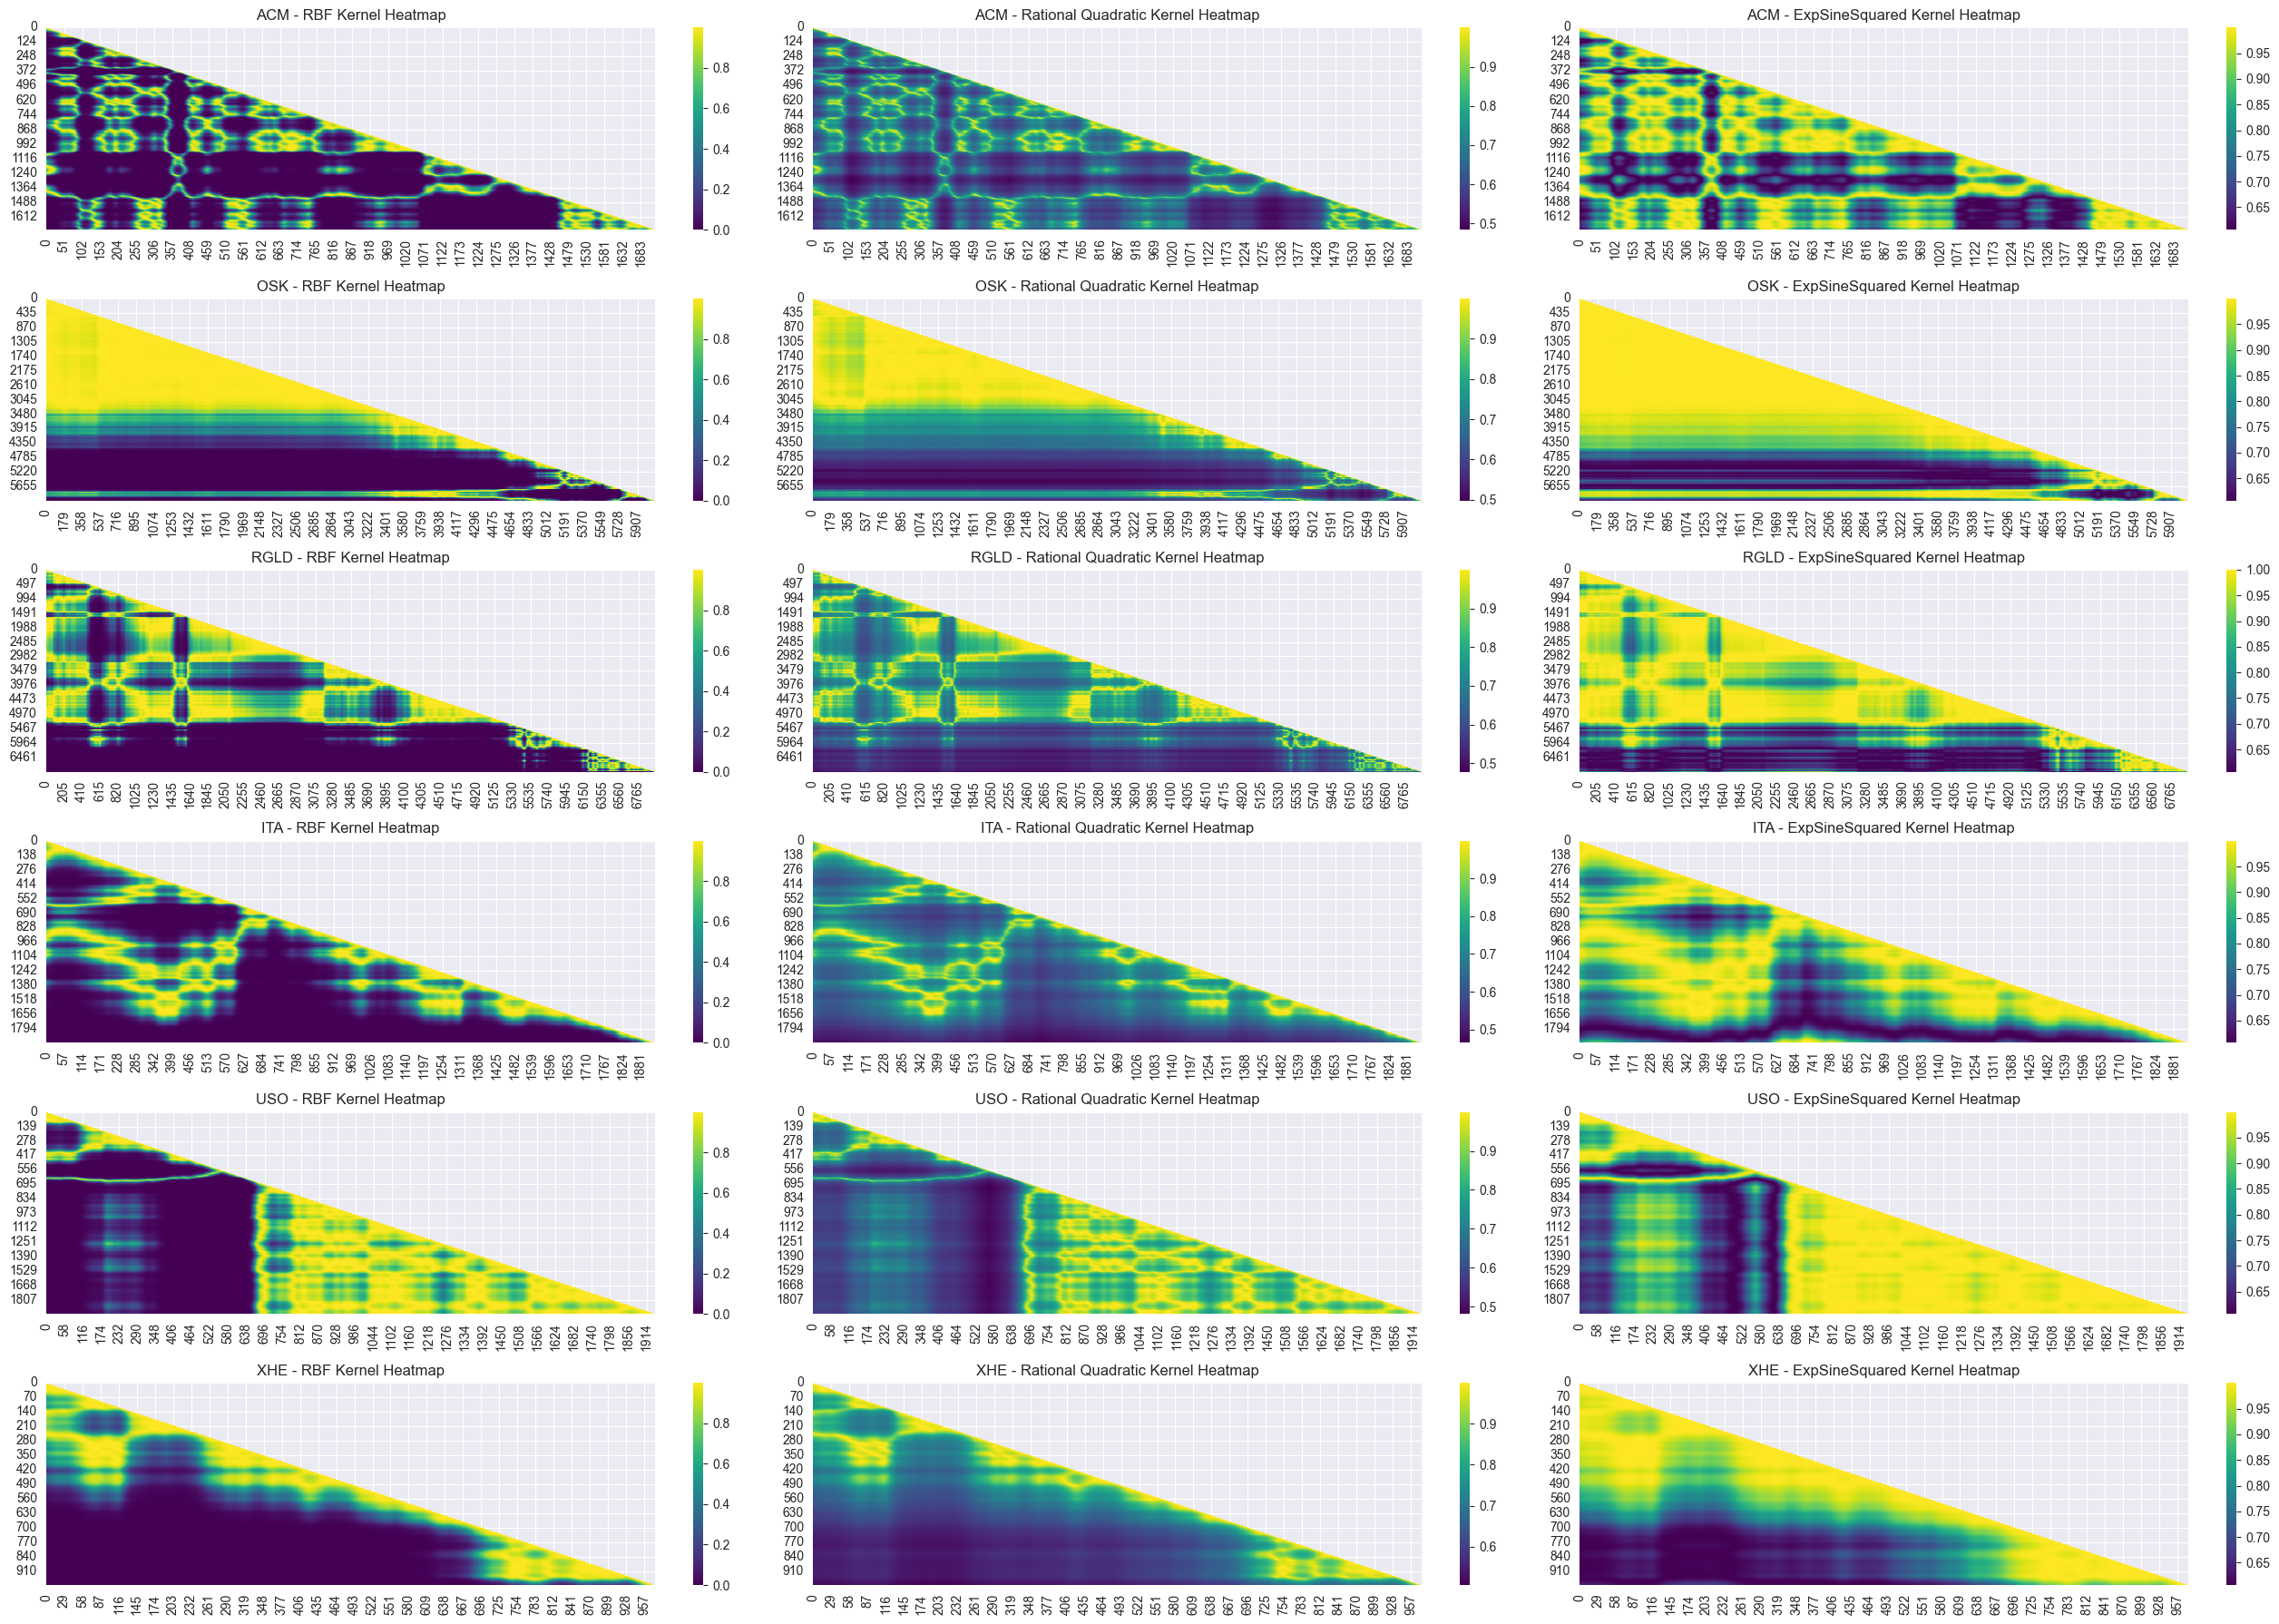

In [44]:
independent_variable = [f'Lag {x}' for x in range(1, 15 + 1)]
target_variable = '30 Day Avg'

kernel_test = (ConstantKernel(1.0, (1e-3, 1e3)) *
               # DotProduct() *
               RBF(length_scale=1.5, length_scale_bounds=(1e-7, 1e7)) +
               WhiteKernel(noise_level=1e-5))

kernel_test2 = (ConstantKernel(1.0, (1e-3, 1e3)) *
                # DotProduct() *
                RationalQuadratic(length_scale=1.0, alpha=0.1,
                                  length_scale_bounds=(1e-5, 1e5),
                                  alpha_bounds=(1e-5, 1e5)) +
                WhiteKernel(noise_level=1e-5))

kernel_test3 = (ConstantKernel(1.0, (1e-3, 1e3)) *
                DotProduct() +
                RationalQuadratic(length_scale=1.0, alpha=0.1,
                                  length_scale_bounds=(1e-5, 1e5),
                                  alpha_bounds=(1e-5, 1e5)) +
                WhiteKernel(noise_level=1e-5))

kernel_test4 = (ConstantKernel(1.0, (1e-3, 1e3)) *
                DotProduct() +
                ExpSineSquared(length_scale=2, periodicity=20.0,
                               length_scale_bounds=(0.01, 10),
                               periodicity_bounds=(1e-2, 1e2)) +
                WhiteKernel(noise_level=1e-5))

kernel_test5 = (ConstantKernel(1.0, (1e-3, 1e3)) *
                # DotProduct() *
                ExpSineSquared(length_scale=2, periodicity=20.0,
                               length_scale_bounds=(0.01, 10),
                               periodicity_bounds=(1e-2, 1e2)) +
                WhiteKernel(noise_level=1e-5))

plot_variables = [
    [kernel_test, 'RBF'],
    [kernel_test2, 'Rational Quadratic'],
    # [kernel_test3, 'Linear-Rational Quadratic'],
    # [kernel_test4, 'Linear-ExpSineSquared'],
    [kernel_test5, 'ExpSineSquared'],

]

fig, axes = plt.subplots(6, 3, figsize=(26, 18))
# axes = axes.flatten()
for i, ticker in enumerate(assets_analysis.keys()):
    for t, plot_var in enumerate(plot_variables):
        x_features = assets_analysis[ticker]['data'][independent_variable].to_numpy()
        xcov = plot_var[0](x_features, x_features)
        sns.heatmap(xcov, cmap='viridis', mask=np.triu(np.ones_like(xcov, dtype=bool)), cbar=True, ax=axes[i, t])
        axes[i, t].set_title(f"{ticker} - {plot_var[1]} Kernel Heatmap")

plt.tight_layout()
plt.savefig(f"plots/lag_feature_kernels.png")
plt.show()

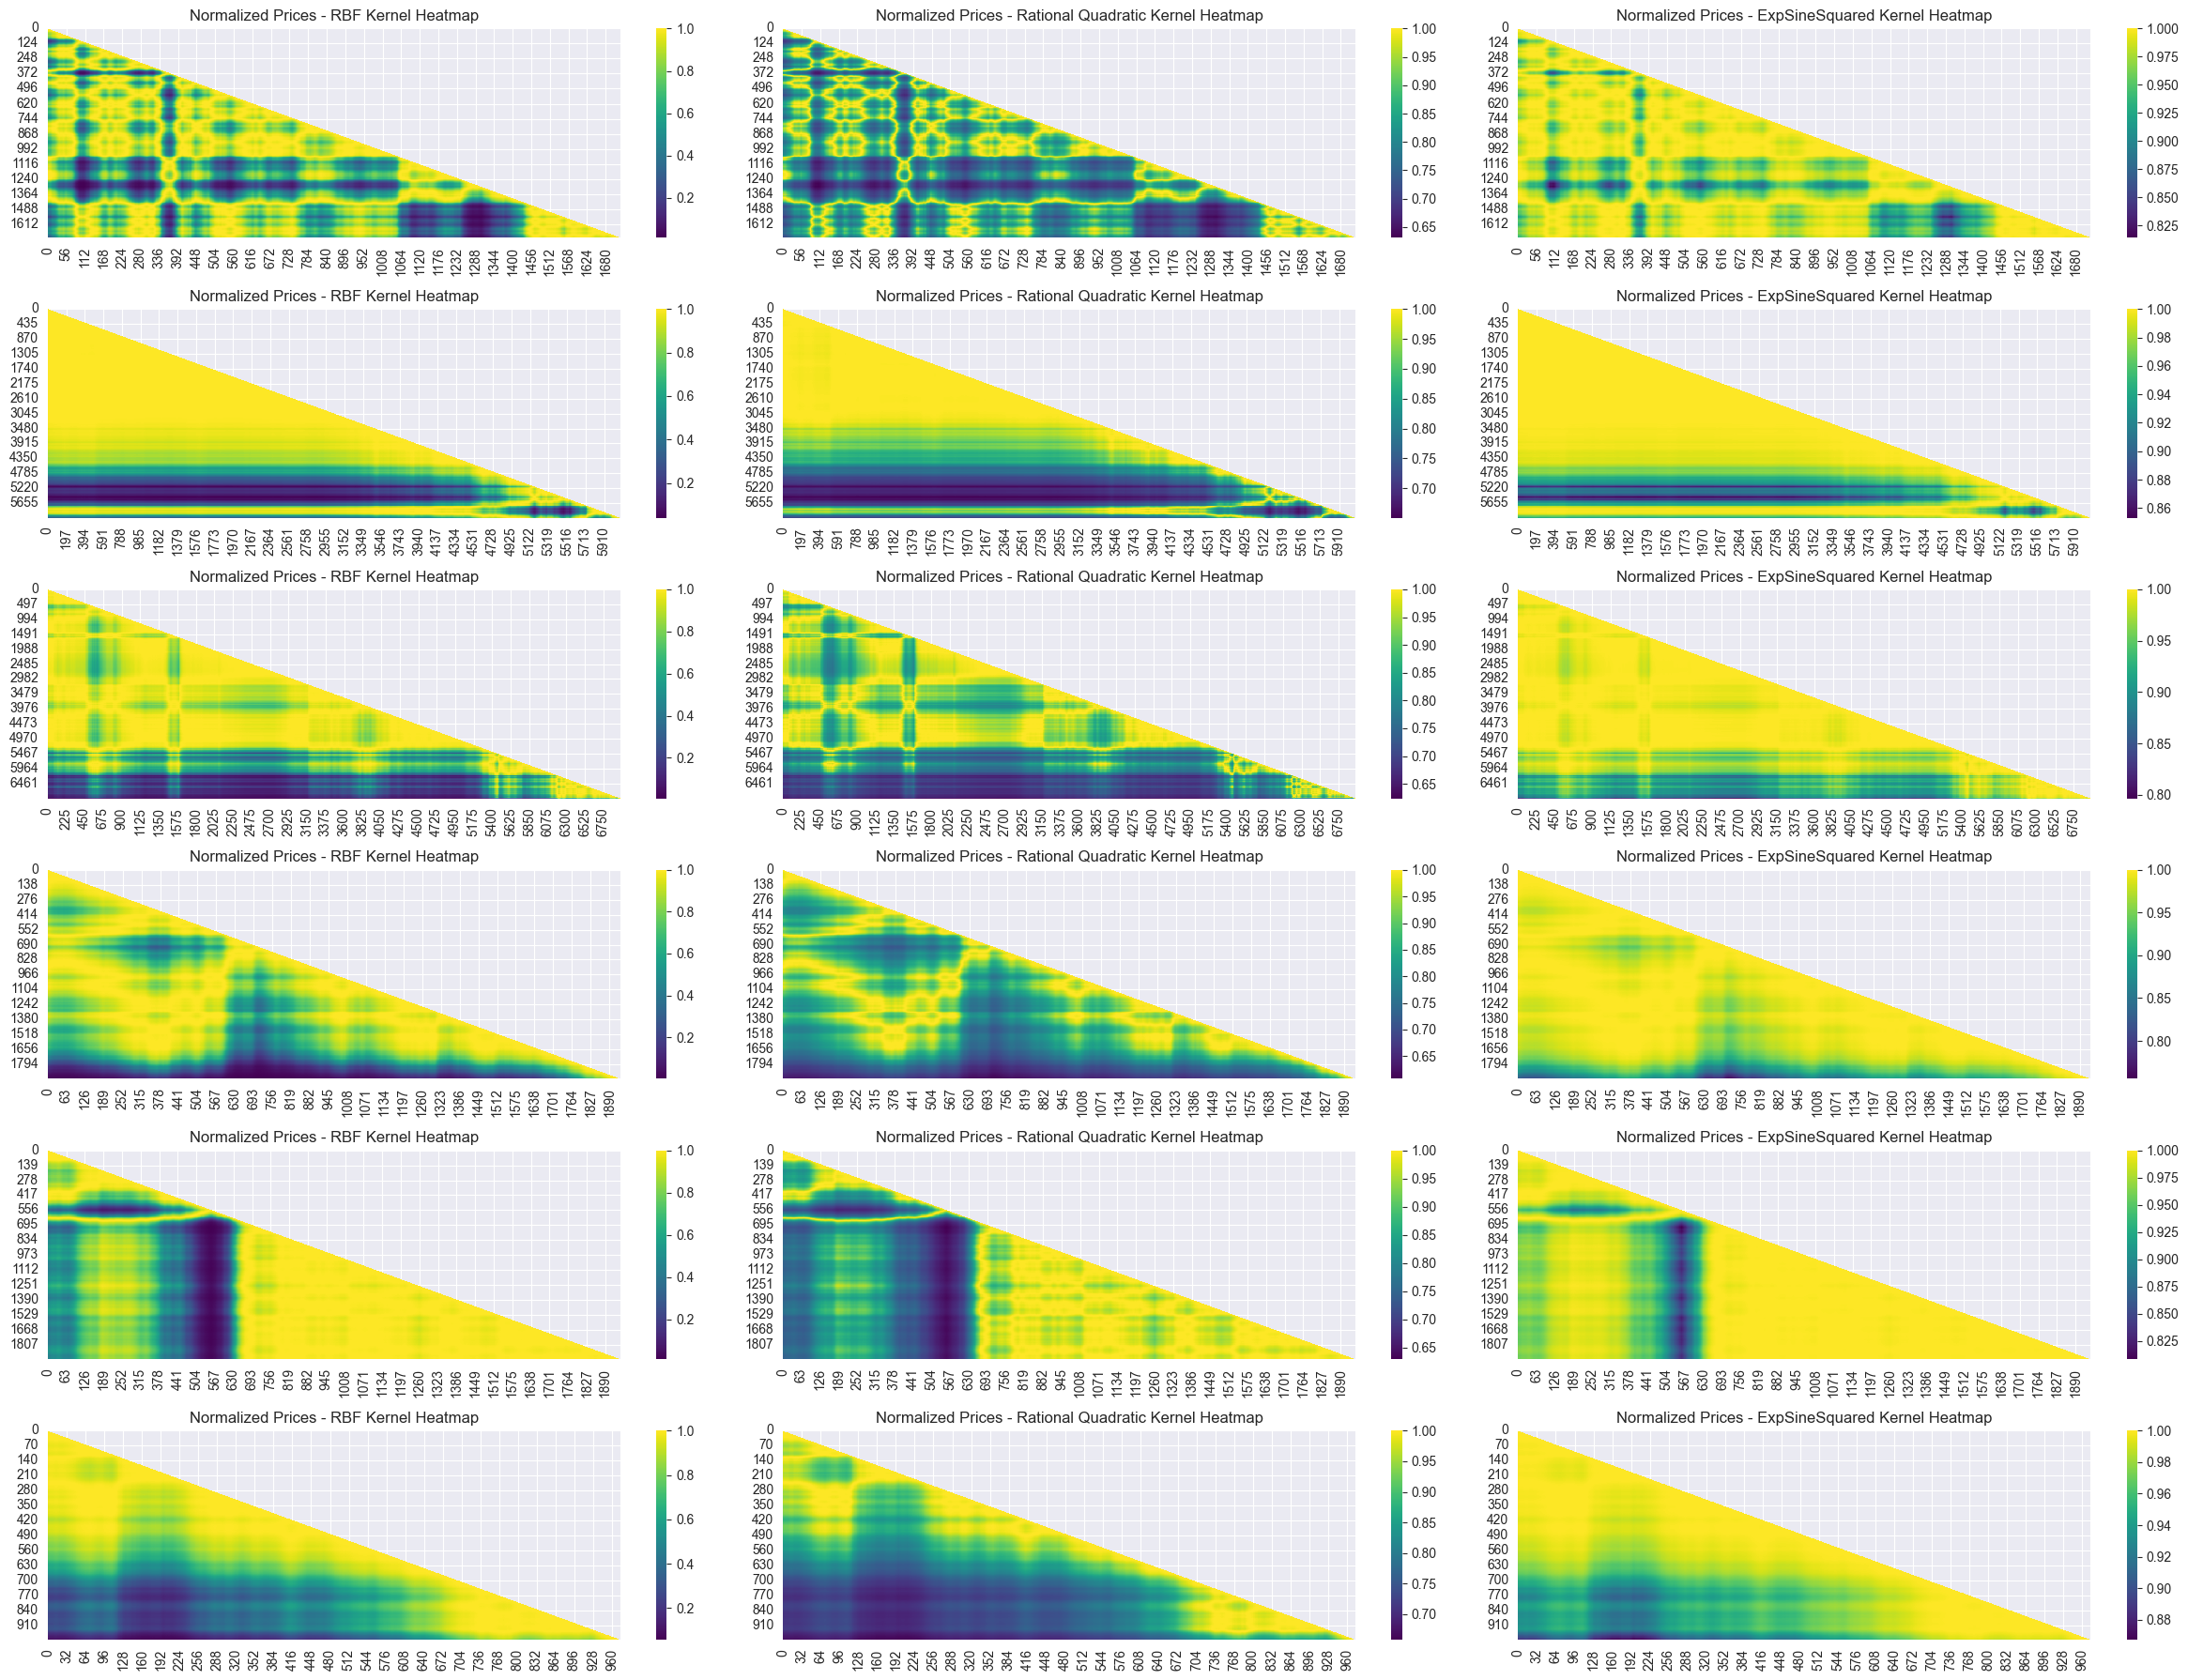

In [42]:
target_variable = '30 Day Avg'
fig, axes = plt.subplots(6, 3, figsize=(26, 18))
# axes = axes.flatten()
for i, ticker in enumerate(assets_analysis.keys()):
    for t, plot_var in enumerate(plot_variables):
        y_features = assets_analysis[ticker]['data'][target_variable].to_numpy().reshape(-1, 1)
        xcov = plot_var[0](y_features, y_features)
        sns.heatmap(xcov, cmap='viridis', mask=np.triu(np.ones_like(xcov, dtype=bool)), cbar=True, ax=axes[i, t])
        axes[i, t].set_title(f"Normalized Prices - {plot_var[1]} Kernel Heatmap")

plt.tight_layout()
plt.savefig(f"plots/predicted_val_kernels.png")
plt.show()

In [ ]:
# scale the data


## Modeling Methodology

When an investor wants to rebalance their portfolio, they want to know the future expected price relative to the risk. For our model the output needs to be a a distribution of future prices, that will tell an investor the range as to which prices will fall and what is the most likely price. To make forecasts into the future we need causality. The following methodology incorporates causality by using kernel ridge regression as an auto-regressive ARMA model with p lags and a q size window for the moving average. r is the number of time steps to forecast. The logical flow of the modeling framework is listed below.

- Smooth the normalized prices using a moving average window of q
- Create the p lags of the smoothed prices that will act as the feature variables to the autoregressive model.
- The smoothed price at time t is the target variable
- Train the kernel ridge regression modeling using timeseries cv split and choose the best kernel and alpha parameter to use for predicting future prices.
- To make predictions of r time steps, the model needs to predict time step t, use time t prediction as a lag variable for prediction time t + 1, and do the same for time t+ 2 all the way through to time t + r. This can be a recursive function



In [3]:
# create the raw dataset to get the predictor and target variables
# read in the data for the below ticker
ticker = 'RGLD'
df_asset = pd.read_parquet(f'data/{ticker}.parquet')
split_record = int(len(df_asset)*0.8)
df_asset_train = df_asset.iloc[:split_record]
df_asset_test = df_asset.iloc[split_record:]

# create the 30 day moving average target variable and the 15 lag feature variables
df_asset_train['30 Day Avg'] = df_asset_train['Adj Close'].rolling(window=30).mean()
df_asset_train['30 Day Avg future value'] = df_asset_train['30 Day Avg'].shift(-6)
lag_value = 15
for lag in range(lag_value):
    lag_val = lag + 1
    df_asset_train[f'Lag {lag_val}'] = df_asset_train['30 Day Avg'].shift(lag_val)
df_asset_train = df_asset_train.dropna()
df_asset_train.to_parquet("data/rgld_train.parquet")
print(df_asset_train.shape)
df_asset_train.head()

(8922, 23)


/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_92347/3355286525.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_train['30 Day Avg'] = df_asset_train['Adj Close'].rolling(window=30).mean()
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_92347/3355286525.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_train['30 Day Avg future value'] = df_asset_train['30 Day Avg'].shift(-6)
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_92347/3355286525.py:15: Set

,Adj Close,Close,High,Low,Open,Volume,30 Day Avg,30 Day Avg future value,Lag 1,Lag 2,...,Lag 6,Lag 7,Lag 8,Lag 9,Lag 10,Lag 11,Lag 12,Lag 13,Lag 14,Lag 15
Date,,,,,,,,,,,,,,,,,,,,,
1981-08-11,2.831146,3.750,3.875,3.750,3.750,18800,2.431641,2.573198,2.403330,2.381310,...,2.305812,2.283792,2.258626,2.230315,2.198858,2.167401,2.129652,2.098195,2.076175,2.060446
1981-08-12,2.831146,3.750,3.875,3.750,3.750,6100,2.459953,2.590500,2.431641,2.403330,...,2.324687,2.305812,2.283792,2.258626,2.230315,2.198858,2.167401,2.129652,2.098195,2.076175
1981-08-13,2.736776,3.625,3.875,3.625,3.750,11800,2.485118,2.607801,2.459953,2.431641,...,2.343561,2.324687,2.305812,2.283792,2.258626,2.230315,2.198858,2.167401,2.129652,2.098195
1981-08-14,2.736776,3.625,3.750,3.625,3.625,4900,2.510284,2.620384,2.485118,2.459953,...,2.359290,2.343561,2.324687,2.305812,2.283792,2.258626,2.230315,2.198858,2.167401,2.129652
1981-08-17,2.642405,3.500,3.625,3.500,3.625,14300,2.532304,2.632967,2.510284,2.485118,...,2.381310,2.359290,2.343561,2.324687,2.305812,2.283792,2.258626,2.230315,2.198858,2.167401


In [2]:
data_load = DataLoader(data_path='data/rgld_train.parquet')
auto_kernel = KernelAutoregressiveModel(forecast_horizon=7, n_jobs=2)

independent_variables = [f'Lag {x + 1}' for x in range(15)]
data_load.load_data(x=independent_variables, y=['30 Day Avg'], actuals=['30 Day Avg future value'])
walks = WalkForwardValidator(
    model=auto_kernel,
    data_loader=data_load,
    ticker='RGLD',
    lags=15,
    # forecast_horizon=5,
    # n_jobs=2,
    window_size=2000,
    min_window_size=2000,
    n_parallel_jobs=2,
    use_scaling=True,
    window_type='sliding'
)
walks.run_walk_forward_validation(target_variable='30 Day Avg')

INFO:auto_kernel_ensemble:Created 5 kernel configurations
INFO:data_loader:Loading data from data/rgld_train.parquet
INFO:data_loader:Loaded data: 8922 rows, 17 columns
INFO:data_loader:Date range: 1981-08-11 00:00:00 to 2016-12-22 00:00:00
INFO:walk_forward:Initialized walk-forward validator: window_size=2000, min_window_size=2000, step_size=1
INFO:walk_forward:Starting walk-forward validation for RGLD
INFO:data_loader:Generated 6922 sliding time windows
INFO:walk_forward:Running 6922 predictions with 15 features
Running Walk Forward Validation: 100%|██████████| 6922/6922 [3:13:50<00:00,  1.68s/it]  


In [3]:
results_df = pd.DataFrame(walks.results_list)
results_df.head()

,date,actual_value,prediction,best_kernel,best_alpha,retrain
0,1989-07-10,[[2.0462903499603273]],[2.074411147774111],Sum,None,True
1,1989-07-11,[[2.049436056613922]],[2.0652462735191115],Sum,None,False
2,1989-07-12,[[2.052581763267517]],[2.0762282608184814],Sum,None,False
3,1989-07-13,[[2.052581763267517]],[2.0837641369796183],Sum,None,False
4,1989-07-14,[[2.0494360446929933]],[2.0720581856095124],Sum,None,False


In [4]:
# save the results
results_df.to_parquet("data/rgld_walk_forward_results.parquet")

In [3]:
results_df = pd.read_parquet("data/rgld_walk_forward_results.parquet")
results_df.head()

,date,actual_value,prediction,best_kernel,best_alpha,retrain
0,1989-07-10,[[2.0462903499603273]],[2.074411147774111],Sum,None,True
1,1989-07-11,[[2.049436056613922]],[2.0652462735191115],Sum,None,False
2,1989-07-12,[[2.052581763267517]],[2.0762282608184814],Sum,None,False
3,1989-07-13,[[2.052581763267517]],[2.0837641369796183],Sum,None,False
4,1989-07-14,[[2.0494360446929933]],[2.0720581856095124],Sum,None,False


In [5]:
results_df['actual'] = results_df['actual_value'].apply(lambda x: x[0][0])
results_df['predicted'] = results_df['prediction'].apply(lambda x: x[0])
results_df.head()

,date,actual_value,prediction,best_kernel,best_alpha,retrain,actual,predicted
0,1989-07-10,[[2.0462903499603273]],[2.074411147774111],Sum,None,True,2.046290,2.074411
1,1989-07-11,[[2.049436056613922]],[2.0652462735191115],Sum,None,False,2.049436,2.065246
2,1989-07-12,[[2.052581763267517]],[2.0762282608184814],Sum,None,False,2.052582,2.076228
3,1989-07-13,[[2.052581763267517]],[2.0837641369796183],Sum,None,False,2.052582,2.083764
4,1989-07-14,[[2.0494360446929933]],[2.0720581856095124],Sum,None,False,2.049436,2.072058


<Axes: >

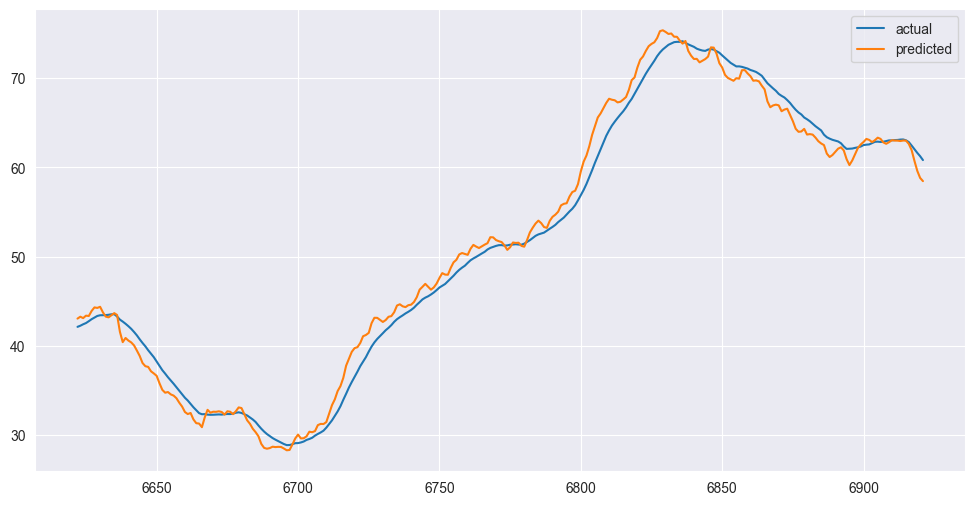

In [17]:
results_df.iloc[-300:][['actual', 'predicted']].plot(figsize=(12, 6))

In [19]:
# calculate teh regression metrics
mse = mean_squared_error(results_df['actual'], results_df['predicted'])
mae = mean_absolute_error(results_df['actual'], results_df['predicted'])
r2 = r2_score(results_df['actual'], results_df['predicted'])
print(f"MSE: {mse}, MAE: {mae}, R2: {r2}")

MSE: 0.6290857471219748, MAE: 0.431131729686941, R2: 0.9985822131241298


0.057710997537398286
-0.002519270776231363
0.0


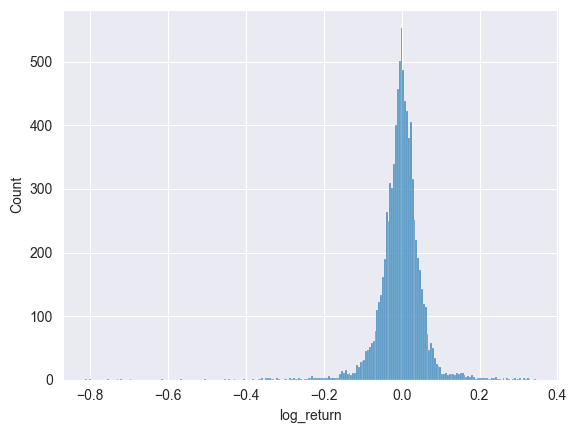

In [4]:
# calculate the 7-day log return and plot the distribution
training_data = pd.read_parquet('data/rgld_train.parquet')
training_data['log_return'] = np.log(training_data['30 Day Avg'] / training_data['30 Day Avg'].shift(-7))
training_data[['30 Day Avg', 'log_return']].head(100)
sns.histplot(training_data['log_return'])
print(training_data['log_return'].std())
print(training_data['log_return'].mean())
print(training_data['log_return'].median())

In [2]:
metrics = ForecastingMetrics(ticker='RGLD', actuals_file='data/rgld_train.parquet')

INFO:metrics:            Adj Close  Close   High    Low   Open  Volume  30 Day Avg  \
Date                                                                    
1981-08-11   2.831146  3.750  3.875  3.750  3.750   18800    2.431641   
1981-08-12   2.831146  3.750  3.875  3.750  3.750    6100    2.459953   
1981-08-13   2.736776  3.625  3.875  3.625  3.750   11800    2.485118   
1981-08-14   2.736776  3.625  3.750  3.625  3.625    4900    2.510284   
1981-08-17   2.642405  3.500  3.625  3.500  3.625   14300    2.532304   

            30 Day Avg future value     Lag 1     Lag 2  ...     Lag 6  \
Date                                                     ...             
1981-08-11                 2.573198  2.403330  2.381310  ...  2.305812   
1981-08-12                 2.590500  2.431641  2.403330  ...  2.324687   
1981-08-13                 2.607801  2.459953  2.431641  ...  2.343561   
1981-08-14                 2.620384  2.485118  2.459953  ...  2.359290   
1981-08-17                 2.63

In [5]:
metrics.calculate_sample_metrics()

INFO:root:        date  30 Day Avg_sample_0_mean  30 Day Avg_sample_0_std  \
0 1989-08-17                  2.018944                 0.088325   
1 1990-11-20                  0.520923                 0.080791   
2 2003-07-25                 16.969211                 0.107303   
3 1989-08-29                  2.265733                 0.088925   
4 2011-02-18                 39.851922                 0.345790   

   30 Day Avg_sample_0_min  30 Day Avg_sample_0_max  30 Day Avg_sample_0_97_5  \
0                 1.720879                 2.344055                  2.206712   
1                 0.273432                 0.800941                  0.665489   
2                16.596788                17.337500                 17.181293   
3                 2.002941                 2.522852                  2.415802   
4                38.876635                41.054278                 40.432329   

   30 Day Avg_sample_0_2_5  Adj Close      Close       High  ...      Lag 8  \
0                 1.8

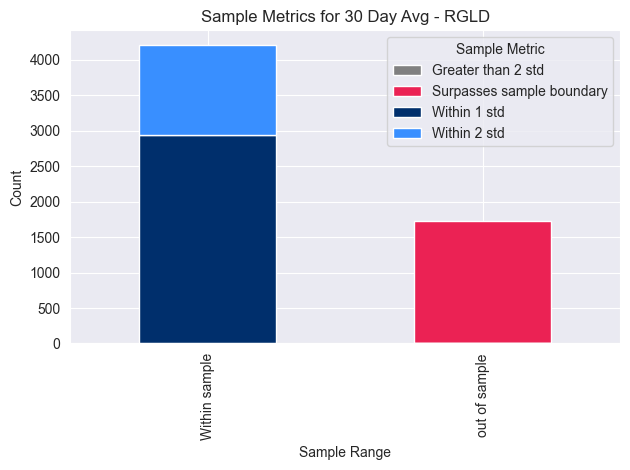

In [6]:
metrics.plot_sample_metrics()

In [10]:
metrics.forecasts_df['30 Day Avg_sample_0_std'].mean()

np.float64(0.13371006385082856)

## Test Set Predictions

Run the same walk forward validation process on the test set to see if the method works

In [14]:
# save the test data with the some of the training data to use as modeling training data
ticker = 'RGLD'
df_asset = pd.read_parquet(f'data/{ticker}.parquet')
split_record = int(len(df_asset)*0.8)
df_asset_train = df_asset.iloc[:split_record]
split_record = split_record - 2040

df_asset_test = df_asset.iloc[split_record:]

# create the 30 day moving average target variable and the 15 lag feature variables
df_asset_test['30 Day Avg'] = df_asset_test['Adj Close'].rolling(window=30).mean()
df_asset_test['30 Day Avg future value'] = df_asset_test['30 Day Avg'].shift(-6)
lag_value = 15
for lag in range(lag_value):
    lag_val = lag + 1
    df_asset_test[f'Lag {lag_val}'] = df_asset_test['30 Day Avg'].shift(lag_val)
df_asset_test = df_asset_test.dropna()
df_asset_test.to_parquet("data/rgld_test.parquet")
print(df_asset_test.shape)
df_asset_test.head()

(4234, 23)


/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_97236/3288356551.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_test['30 Day Avg'] = df_asset_test['Adj Close'].rolling(window=30).mean()
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_97236/3288356551.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_test['30 Day Avg future value'] = df_asset_test['30 Day Avg'].shift(-6)
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_97236/3288356551.py:16: Setting

,Adj Close,Close,High,Low,Open,Volume,30 Day Avg,30 Day Avg future value,Lag 1,Lag 2,...,Lag 6,Lag 7,Lag 8,Lag 9,Lag 10,Lag 11,Lag 12,Lag 13,Lag 14,Lag 15
Date,,,,,,,,,,,,,,,,,,,,,
2009-01-30,39.584732,48.080002,49.180000,46.520000,49.000000,834500,37.464249,37.634033,37.333561,37.089977,...,36.095955,35.881861,35.659793,35.443774,35.276304,35.142024,34.976872,34.931963,34.883784,34.759337
2009-02-02,38.679100,46.980000,48.369999,46.270000,47.020000,678400,37.559544,37.481458,37.464249,37.333561,...,36.438733,36.095955,35.881861,35.659793,35.443774,35.276304,35.142024,34.976872,34.931963,34.883784
2009-02-03,38.201595,46.400002,47.369999,45.549999,47.099998,665400,37.681664,37.376350,37.559544,37.464249,...,36.638088,36.438733,36.095955,35.881861,35.659793,35.443774,35.276304,35.142024,34.976872,34.931963
2009-02-04,37.995750,46.150002,47.430000,45.419998,46.400002,660700,37.721028,37.245718,37.681664,37.559544,...,36.905707,36.638088,36.438733,36.095955,35.881861,35.659793,35.443774,35.276304,35.142024,34.976872
2009-02-05,37.962818,46.110001,47.750000,45.720001,47.500000,594000,37.753268,37.061571,37.721028,37.681664,...,37.089977,36.905707,36.638088,36.438733,36.095955,35.881861,35.659793,35.443774,35.276304,35.142024


In [16]:
data_load = DataLoader(data_path='data/rgld_test.parquet')
auto_kernel = KernelAutoregressiveModel(forecast_horizon=7, n_jobs=2)

independent_variables = [f'Lag {x + 1}' for x in range(15)]
data_load.load_data(x=independent_variables, y=['30 Day Avg'], actuals=['30 Day Avg future value'])
walks = WalkForwardValidator(
    model=auto_kernel,
    data_loader=data_load,
    ticker='RGLD',
    lags=15,
    # forecast_horizon=5,
    # n_jobs=2,
    window_size=2000,
    min_window_size=2000,
    n_parallel_jobs=2,
    use_scaling=True,
    window_type='sliding'
)
walks.run_walk_forward_validation(target_variable='30 Day Avg')

INFO:auto_kernel_ensemble:Created 5 kernel configurations
INFO:data_loader:Loading data from data/rgld_test.parquet
INFO:data_loader:Loaded data: 4234 rows, 17 columns
INFO:data_loader:Date range: 2009-01-30 00:00:00 to 2025-11-26 00:00:00
INFO:walk_forward:Initialized walk-forward validator: window_size=2000, min_window_size=2000, step_size=1
INFO:walk_forward:Starting walk-forward validation for RGLD
INFO:data_loader:Generated 2234 sliding time windows
INFO:walk_forward:Running 2234 predictions with 15 features
Running Walk Forward Validation: 100%|██████████| 2234/2234 [1:08:17<00:00,  1.83s/it]


In [21]:
results_df = pd.DataFrame(walks.results_list)
results_df.to_parquet("data/rgld_test_walk_forward_results.parquet")

<Axes: >

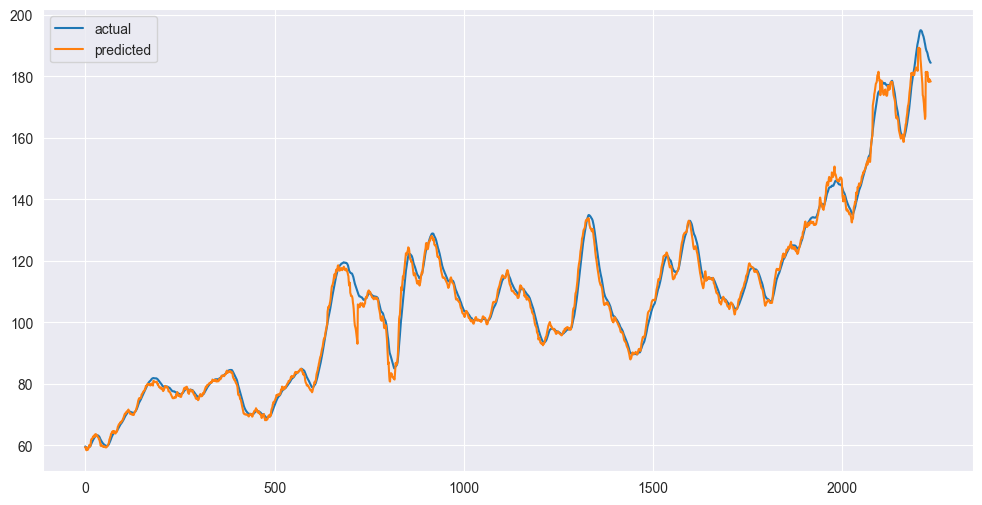

In [23]:
results_df['actual'] = results_df['actual_value'].apply(lambda x: x[0][0])
results_df['predicted'] = results_df['prediction'].apply(lambda x: x[0])
results_df[['actual', 'predicted']].plot(figsize=(12, 6))

In [24]:
# calculate teh regression metrics
mse = mean_squared_error(results_df['actual'], results_df['predicted'])
mae = mean_absolute_error(results_df['actual'], results_df['predicted'])
r2 = r2_score(results_df['actual'], results_df['predicted'])
print(f"MSE: {mse}, MAE: {mae}, R2: {r2}")

MSE: 7.938735829080425, MAE: 1.7586715471160228, R2: 0.9902001145642616


In [8]:
# What is the risk when guessing wrong
results_df = pd.read_parquet("data/rgld_test_walk_forward_results.parquet")
results_df['actual'] = results_df['actual_value'].apply(lambda x: x[0][0])
results_df['predicted'] = results_df['prediction'].apply(lambda x: x[0])
results_df.head()

,date,actual_value,prediction,best_kernel,best_alpha,retrain,actual,predicted
0,2017-01-10,[[59.657349014282225]],[59.34351512537256],Sum,None,True,59.657349,59.343515
1,2017-01-11,[[59.537638346354164]],[59.48561249271777],Sum,None,False,59.537638,59.485612
2,2017-01-12,[[59.39392382303874]],[58.735611514759114],Sum,None,False,59.393924,58.735612
3,2017-01-13,[[59.327654647827146]],[58.4117583863468],Sum,None,False,59.327655,58.411758
4,2017-01-17,[[59.33080037434896]],[58.724021988802676],Sum,None,False,59.330800,58.724022


In [9]:
actual_results = pd.read_parquet('data/rgld_test.parquet')
actual_results['date'] = actual_results.index
actual_results['log_return'] = np.log(actual_results['Adj Close'].shift(-6) / actual_results['Adj Close'].shift(1))
actual_results.head(15)

,Adj Close,Close,High,Low,Open,Volume,30 Day Avg,30 Day Avg future value,Lag 1,Lag 2,...,Lag 8,Lag 9,Lag 10,Lag 11,Lag 12,Lag 13,Lag 14,Lag 15,date,log_return
Date,,,,,,,,,,,,,,,,,,,,,
2009-01-30,39.584732,48.080002,49.180000,46.520000,49.000000,834500,37.464249,37.634033,37.333561,37.089977,...,35.659793,35.443774,35.276304,35.142024,34.976872,34.931963,34.883784,34.759337,2009-01-30,NaN
2009-02-02,38.679100,46.980000,48.369999,46.270000,47.020000,678400,37.559544,37.481458,37.464249,37.333561,...,35.881861,35.659793,35.443774,35.276304,35.142024,34.976872,34.931963,34.883784,2009-02-02,-0.116562
2009-02-03,38.201595,46.400002,47.369999,45.549999,47.099998,665400,37.681664,37.376350,37.559544,37.464249,...,36.095955,35.881861,35.659793,35.443774,35.276304,35.142024,34.976872,34.931963,2009-02-03,-0.059640
2009-02-04,37.995750,46.150002,47.430000,45.419998,46.400002,660700,37.721028,37.245718,37.681664,37.559544,...,36.438733,36.095955,35.881861,35.659793,35.443774,35.276304,35.142024,34.976872,2009-02-04,-0.054020
2009-02-05,37.962818,46.110001,47.750000,45.720001,47.500000,594000,37.753268,37.061571,37.721028,37.681664,...,36.638088,36.438733,36.095955,35.881861,35.659793,35.443774,35.276304,35.142024,2009-02-05,-0.082393
2009-02-06,37.855801,45.980000,46.840000,45.400002,45.950001,783600,37.733445,37.025345,37.753268,37.721028,...,36.905707,36.638088,36.438733,36.095955,35.881861,35.659793,35.443774,35.276304,2009-02-06,0.011428
2009-02-09,35.427013,43.029999,45.750000,42.759998,45.750000,852400,37.634033,37.009977,37.733445,37.753268,...,37.089977,36.905707,36.638088,36.438733,36.095955,35.881861,35.659793,35.443774,2009-02-09,-0.005452
2009-02-10,35.229424,42.790001,44.820000,42.610001,43.200001,936700,37.481458,36.912003,37.634033,37.733445,...,37.333561,37.089977,36.905707,36.638088,36.438733,36.095955,35.881861,35.659793,2009-02-10,0.017052
2009-02-11,36.439713,44.259998,45.220001,42.360001,42.799999,747600,37.376350,36.909532,37.481458,37.634033,...,37.464249,37.333561,37.089977,36.905707,36.638088,36.438733,36.095955,35.881861,2009-02-11,0.049024


In [10]:
# merge the actual adj close price with the predicted price and plot the distribution
results_df = results_df.merge(actual_results[['date', 'Adj Close', 'log_return', 'Lag 1']], on='date', how='left')
results_df

,date,actual_value,prediction,best_kernel,best_alpha,retrain,actual,predicted,Adj Close,log_return,Lag 1
0,2017-01-10,[[59.657349014282225]],[59.34351512537256],Sum,None,True,59.657349,59.343515,60.497974,0.034625,59.678352
1,2017-01-11,[[59.537638346354164]],[59.48561249271777],Sum,None,False,59.537638,59.485612,60.208973,0.026369,59.657349
2,2017-01-12,[[59.39392382303874]],[58.735611514759114],Sum,None,False,59.393924,58.735612,60.118671,0.053159,59.537638
3,2017-01-13,[[59.327654647827146]],[58.4117583863468],Sum,None,False,59.327655,58.411758,60.669537,0.074097,59.393924
4,2017-01-17,[[59.33080037434896]],[58.724021988802676],Sum,None,False,59.330800,58.724022,61.753269,0.063999,59.327655
...,...,...,...,...,...,...,...,...,...,...,...
2229,2025-11-20,[[185.24499969482423]],[178.20312036696498],Sum,None,False,185.245000,178.203120,183.789993,NaN,185.543000
2230,2025-11-21,[[184.91599985758464]],[178.909214339548],Sum,None,False,184.916000,178.909214,184.600006,NaN,185.245000
2231,2025-11-24,[[184.62933298746745]],[178.6082269388184],Sum,None,False,184.629333,178.608227,190.869995,NaN,184.916000
2232,2025-11-25,[[184.38600006103516]],[178.20955392114928],Sum,None,False,184.386000,178.209554,192.380005,NaN,184.629333


In [14]:
results_df['predicted return'] = np.log(results_df['predicted'] / results_df['Lag 1'])
results_df['buy sell signal'] = results_df['predicted return'].apply(lambda x: 'buy' if x >= 0 else 'sell')

def buy_sell_signal2(x):
    if x >= 0.02:
        return 'buy'
    elif x <= -0.02:
        return 'sell'
    else:
        return 'hold'

results_df['buy sell signal2'] = results_df['predicted return'].apply(lambda x: buy_sell_signal2(x=x))
results_df.head(15)

,date,actual_value,prediction,best_kernel,best_alpha,retrain,actual,predicted,Adj Close,log_return,Lag 1,predicted return,buy sell signal,buy sell signal2
0,2017-01-10,[[59.657349014282225]],[59.34351512537256],Sum,None,True,59.657349,59.343515,60.497974,0.034625,59.678352,-0.005626,sell,hold
1,2017-01-11,[[59.537638346354164]],[59.48561249271777],Sum,None,False,59.537638,59.485612,60.208973,0.026369,59.657349,-0.002883,sell,hold
2,2017-01-12,[[59.39392382303874]],[58.735611514759114],Sum,None,False,59.393924,58.735612,60.118671,0.053159,59.537638,-0.013562,sell,hold
3,2017-01-13,[[59.327654647827146]],[58.4117583863468],Sum,None,False,59.327655,58.411758,60.669537,0.074097,59.393924,-0.016675,sell,hold
4,2017-01-17,[[59.33080037434896]],[58.724021988802676],Sum,None,False,59.330800,58.724022,61.753269,0.063999,59.327655,-0.010227,sell,hold
5,2017-01-18,[[59.260437647501625]],[59.19656241040541],Sum,None,False,59.260438,59.196562,61.518448,0.017397,59.330800,-0.002265,sell,hold
6,2017-01-19,[[59.18438250223796]],[58.73552837395271],Sum,None,False,59.184383,58.735528,61.563595,0.034059,59.260438,-0.008897,sell,hold
7,2017-01-20,[[59.16357917785645]],[58.594226129482585],Sum,None,False,59.163579,58.594226,62.114494,0.022196,59.184383,-0.010022,sell,hold
8,2017-01-23,[[59.199031829833984]],[58.89543028130949],Sum,None,False,59.199032,58.895430,63.496250,0.048112,59.163579,-0.004543,sell,hold
9,2017-01-24,[[59.28232332865397]],[59.281445773050464],Sum,None,False,59.282323,59.281446,64.742500,0.015944,59.199032,0.001391,buy,hold


In [19]:
def calc_bets_long(signal: str, actual_return: float):
    if signal == 'buy':
        return actual_return
    else:
        return 0.0

def calc_bets_hedged(signal: str, actual_return: float):
    if signal == 'buy':
        return actual_return
    elif signal == 'hold':
        return 0.0
    else:
        return -actual_return


results_df['bets long'] = results_df.apply(lambda x: calc_bets_long(signal=x['buy sell signal'], actual_return=x['log_return']), axis=1)
results_df['bets long2'] = results_df.apply(lambda x: calc_bets_long(signal=x['buy sell signal2'], actual_return=x['log_return']), axis=1)

results_df['bets hedged'] = results_df.apply(lambda x: calc_bets_hedged(signal=x['buy sell signal'], actual_return=x['log_return']), axis=1)
results_df['bets hedged2'] = results_df.apply(lambda x: calc_bets_hedged(signal=x['buy sell signal2'], actual_return=x['log_return']), axis=1)

# calculate the cumulative returns
results_df['bets long cumulative'] = results_df['bets long'].cumsum()
results_df['bets long cumulative2'] = results_df['bets long2'].cumsum()

results_df['bets hedged cumulative'] = results_df['bets hedged'].cumsum()
results_df['bets hedged cumulative2'] = results_df['bets hedged2'].cumsum()

results_df['cumulative_hold'] = results_df['log_return'].cumsum()

results_df.head(20)

,date,actual_value,prediction,best_kernel,best_alpha,retrain,actual,predicted,Adj Close,log_return,...,buy sell signal2,bets long,bets long2,bets hedged,bets hedged2,bets long cumulative,bets long cumulative2,bets hedged cumulative,bets hedged cumulative2,cumulative_hold
0,2017-01-10,[[59.657349014282225]],[59.34351512537256],Sum,None,True,59.657349,59.343515,60.497974,0.034625,...,hold,0.000000,0.000000,-0.034625,0.000000,0.000000,0.000000,-0.034625,0.000000,0.034625
1,2017-01-11,[[59.537638346354164]],[59.48561249271777],Sum,None,False,59.537638,59.485612,60.208973,0.026369,...,hold,0.000000,0.000000,-0.026369,0.000000,0.000000,0.000000,-0.060994,0.000000,0.060994
2,2017-01-12,[[59.39392382303874]],[58.735611514759114],Sum,None,False,59.393924,58.735612,60.118671,0.053159,...,hold,0.000000,0.000000,-0.053159,0.000000,0.000000,0.000000,-0.114154,0.000000,0.114154
3,2017-01-13,[[59.327654647827146]],[58.4117583863468],Sum,None,False,59.327655,58.411758,60.669537,0.074097,...,hold,0.000000,0.000000,-0.074097,0.000000,0.000000,0.000000,-0.188251,0.000000,0.188251
4,2017-01-17,[[59.33080037434896]],[58.724021988802676],Sum,None,False,59.330800,58.724022,61.753269,0.063999,...,hold,0.000000,0.000000,-0.063999,0.000000,0.000000,0.000000,-0.252250,0.000000,0.252250
5,2017-01-18,[[59.260437647501625]],[59.19656241040541],Sum,None,False,59.260438,59.196562,61.518448,0.017397,...,hold,0.000000,0.000000,-0.017397,0.000000,0.000000,0.000000,-0.269647,0.000000,0.269647
6,2017-01-19,[[59.18438250223796]],[58.73552837395271],Sum,None,False,59.184383,58.735528,61.563595,0.034059,...,hold,0.000000,0.000000,-0.034059,0.000000,0.000000,0.000000,-0.303706,0.000000,0.303706
7,2017-01-20,[[59.16357917785645]],[58.594226129482585],Sum,None,False,59.163579,58.594226,62.114494,0.022196,...,hold,0.000000,0.000000,-0.022196,0.000000,0.000000,0.000000,-0.325902,0.000000,0.325902
8,2017-01-23,[[59.199031829833984]],[58.89543028130949],Sum,None,False,59.199032,58.895430,63.496250,0.048112,...,hold,0.000000,0.000000,-0.048112,0.000000,0.000000,0.000000,-0.374013,0.000000,0.374013
9,2017-01-24,[[59.28232332865397]],[59.281445773050464],Sum,None,False,59.282323,59.281446,64.742500,0.015944,...,hold,0.015944,0.000000,0.015944,0.000000,0.015944,0.000000,-0.358069,0.000000,0.389957


<Axes: >

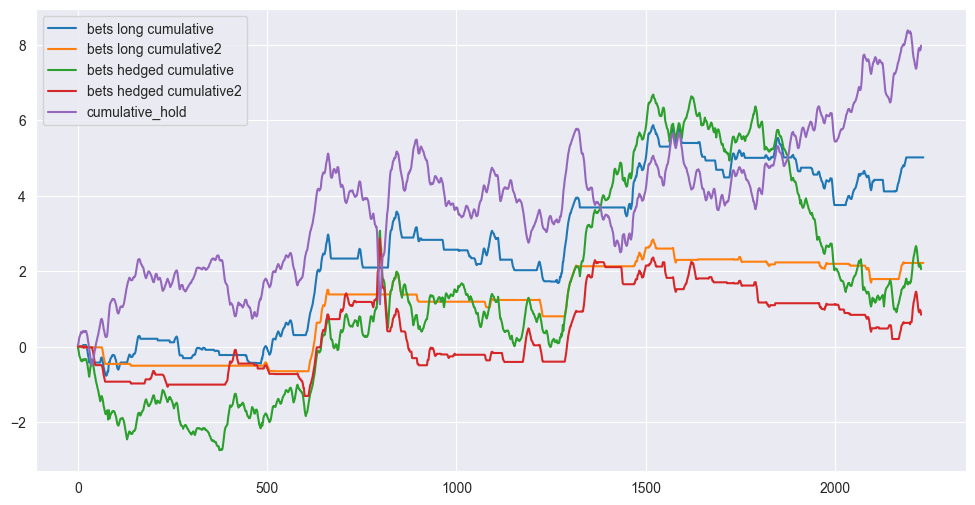

In [20]:
results_df[['bets long cumulative', 'bets long cumulative2', 'bets hedged cumulative', 'bets hedged cumulative2', 'cumulative_hold']].plot(figsize=(12, 6))